In [1]:
# ==============================================================================
# 🛠️ CELL 1: SETUP & CONFIGURATION
# ==============================================================================
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import shape
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import autogen
from dotenv import load_dotenv
import time
from pathlib import Path
from typing import Dict, Any, List, Optional
from Utl import read_from_csv

from autogen import ConversableAgent, UserProxyAgent

# Import Overture Logic from Utl.py
try:
    from Utl import acs_county_data, process_locs_buildings
    print("Loaded Utl.py successfully.")
except ImportError:
    print("❌ Utl.py not found. Please ensure it is in the same folder.")

load_dotenv()
API_KEY = os.getenv("OPENAI_API_KEY", "")
API_BASE = "https://api.ai.it.cornell.edu/"

if not API_KEY:
    raise ValueError("OPENAI_API_KEY not found in .env file")

config_list = [
    {
        "model": "openai.gpt-5-mini", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
    {
        "model": "meta.llama-4-maverick-17b-instruct", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
    {
        "model": "google.gemini-2.5-flash", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
    {
        "model": "xai.grok-3-mini", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
]

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

Loaded Utl.py successfully.


In [2]:
# 2) Deterministic hard checks
# =====================================================================
import io
def hard_check_population(candidate: Dict[str, Any], State_fips, county_fips) -> Dict[str, Any]:
    violations = []
    if not isinstance(candidate, dict):
        return {"ok": False, "violations": ["candidate_not_dict"], "metrics": {}}

    if candidate.get("stage") != "population":
        violations.append("stage_must_be_population")

    clusters = candidate.get("clusters", None)
    if not isinstance(clusters, list) or len(clusters) == 0:
        violations.append("clusters_missing_or_empty")
        return {"ok": False, "violations": violations, "metrics": {"violations": len(violations)}}

    ids = []
    total = 0
    for i, c in enumerate(clusters):
        if not isinstance(c, dict):
            violations.append(f"cluster_{i}_not_dict")
            continue
        cid = c.get("cluster_id")
        if not cid or not isinstance(cid, str):
            violations.append(f"cluster_{i}_missing_cluster_id")
        else:
            ids.append(cid)

        pc = c.get("population_count")
        if not isinstance(pc, int) or pc <= 0:
            violations.append(f"cluster_{i}_population_count_invalid")
        else:
            total += pc

        if not c.get("demographic_summary"):
            violations.append(f"cluster_{i}_missing_demographic_summary")
        if not c.get("behavior_archetype"):
            violations.append(f"cluster_{i}_missing_behavior_archetype")

    if len(ids) != len(set(ids)):
        violations.append("cluster_id_not_unique")

    # --- UPDATED DYNAMIC ACS CHECK WITH TOLERANCE ---
    try:
        filename = f"ACS/{State_fips}_{county_fips}.csv"
        csv_content = read_from_csv(filename)
        df_acs = pd.read_csv(io.StringIO(csv_content))
        ACS_Total = df_acs['Estimate!!Total!!Total population'].iloc[0]
        
        # FIX: Allow a 1% margin of error for smaller LLMs
        tolerance = ACS_Total * 0.02
        
        if abs(total - ACS_Total) > tolerance:
            if total < ACS_Total:
                violations.append(f"total is smaller than ground truth by {abs(total-ACS_Total)}")
            if total > ACS_Total:
                violations.append(f"total is greater than ground truth by {abs(total-ACS_Total)}")
    except Exception as e:
        violations.append(f"Could not validate against ACS ground truth: {e}")

    metrics = {
        "total_population_count": total,
        "num_clusters": len(clusters),
        "violations": len(violations),
    }
    return {"ok": len(violations) == 0, "violations": violations, "metrics": metrics}


def hard_check_activity(candidate: Dict[str, Any], state_fips: str, county_fips: str, clusters: List[Dict[str, Any]] = None) -> Dict[str, Any]:
    tol = 1e-3
    violations = []

    if not isinstance(candidate, dict):
        return {"ok": False, "violations": ["candidate_not_dict"], "metrics": {}}

    if candidate.get("stage") != "activity":
        violations.append("stage_must_be_activity")

    ca = candidate.get("clusters_activity", None)
    if not isinstance(ca, list) or len(ca) == 0:
        violations.append("clusters_activity_missing_or_empty")
        return {"ok": False, "violations": violations, "metrics": {"violations": len(violations)}}

    # Safety check if clusters wasn't passed properly
    if not clusters:
        violations.append("clusters_data_missing_from_kwargs")
        return {"ok": False, "violations": violations, "metrics": {"violations": len(violations)}}

    pop_ids = [c["cluster_id"] for c in clusters if isinstance(c, dict) and "cluster_id" in c]
    ca_ids = []
    bad_rows = 0

    required_keys = ["sleep", "work", "meal", "errand", "leisure"]

    for i, item in enumerate(ca):
        if not isinstance(item, dict):
            violations.append(f"clusters_activity_{i}_not_dict")
            continue
        cid = item.get("cluster_id")
        if not cid:
            violations.append(f"clusters_activity_{i}_missing_cluster_id")
            continue
        ca_ids.append(cid)

        hourly = item.get("hourly_activity", None)
        if not isinstance(hourly, list) or len(hourly) != 24:
            violations.append(f"{cid}_hourly_activity_must_have_24_entries")
            continue

        seen_hours = set()
        for hrow in hourly:
            if not isinstance(hrow, dict):
                violations.append(f"{cid}_hour_row_not_dict")
                bad_rows += 1
                continue

            hour = hrow.get("hour")
            if not isinstance(hour, int) or hour < 0 or hour > 23:
                violations.append(f"{cid}_invalid_hour_value")
                bad_rows += 1
                continue

            seen_hours.add(hour)
            s = 0.0
            for k in required_keys:
                v = hrow.get(k)
                if not isinstance(v, (int, float)):
                    violations.append(f"{cid}_hour_{hour}_{k}_not_number")
                    bad_rows += 1
                    continue
                if v < -tol or v > 1.0 + tol:
                    violations.append(f"{cid}_hour_{hour}_{k}_out_of_range")
                    bad_rows += 1
                s += float(v)

            if abs(s - 1.0) > 5e-2:
                violations.append(f"{cid}_hour_{hour}_shares_sum_not_1 (sum={s:.3f})")
                bad_rows += 1

        if seen_hours != set(range(24)):
            missing = sorted(list(set(range(24)) - seen_hours))
            violations.append(f"{cid}_missing_hours_{missing}")

    missing_clusters = sorted(list(set(pop_ids) - set(ca_ids)))
    extra_clusters = sorted(list(set(ca_ids) - set(pop_ids)))
    if missing_clusters:
        violations.append(f"missing_cluster_ids_in_activity: {missing_clusters}")
    if extra_clusters:
        violations.append(f"unknown_cluster_ids_in_activity: {extra_clusters}")

    metrics = {
        "num_population_clusters": len(pop_ids),
        "num_activity_clusters": len(ca_ids),
        "bad_rows": bad_rows,
        "violations": len(violations),
    }
    return {"ok": len(violations) == 0, "violations": violations, "metrics": metrics}

In [3]:
# 3) Hybrid Verification agents
# =====================================================================
def build_llm_config(model_name: str) -> Dict[str, Any]:
    """
    Cornell gateway expects base_url = API_BASE.
    We pass the model string as provided in MODELS list.
    """
    return {
        "config_list": [
            {
                "model": model_name,
                "base_url": API_BASE,
                "api_key": API_KEY,
            }
        ],
        "temperature": 0.2,
    }


def build_agents(llm_config: Dict[str, Any]):
    user_proxy = UserProxyAgent(
        name="Runner",
        human_input_mode="NEVER",
        max_consecutive_auto_reply=0,
        default_auto_reply="TERMINATE",
        #is_termination_msg=lambda msg: msg.get("content") is not None and "TERMINATE" in msg["content"],
        code_execution_config={"use_docker": False},
    )


    population_agent = ConversableAgent(
        name="PopulationGenerator",
        llm_config=llm_config,
        system_message=(
            "You are the Population Agent.\n"
            #"You MUST call fetch_acs_county_data(county_fips, state_fips) first.\n"
            "Then return ONLY valid JSON with schema:\n"
            "{stage:'population', county_fips:str, state_fips:str, clusters:["
            "{cluster_id:str, population_count:int, demographic_summary:str, behavior_archetype:str}"
            "]}.\n"
            "demographic_summary str should be like Age (18-34: X%, 35-54: Y%, 55+: Z%), Income (Low: X%, Middle: Y%, High: Z%), Education (High School: X%, Some College: Y%, Bachelor's+: Z%), Gender (Male: X%, Female: Y%), Employment (Full-time: X%, Part-time: Y%, Unemployed: Z%), Travel Behavior (Public Transit: High, Car: Moderate)\n"
            "Make sure the generated clusters are corresponding to the ACS margins\n"
            "You must output ONLY valid JSON. No code blocks. No markdown. No extra text. The response must start with { and end with }"
            
        ),
    )

    activity_agent = ConversableAgent(
        name="ActivityGenerator",
        llm_config=llm_config,
        system_message=(
            "You are the Activity Agent.\n"
            "Input will include population clusters.\n"
            "Return ONLY valid JSON with schema:\n"
            "{stage:'activity', clusters_activity:["
            "{cluster_id:str, hourly_activity:["
            "{hour:int, sleep:float, work:float, meal:float, errand:float, leisure:float}"
            " x24]}"
            "]}.\n"
            "Per cluster per hour, shares must sum to 1.\n"
            "You must output ONLY valid JSON. No code blocks. No markdown. No extra text. The response must start with { and end with }"
        ),
    )

    pop_self_verifier = ConversableAgent(
        name="SelfVerifier",
        llm_config=llm_config,
        system_message=(
            "You are a verifier. You will receive candidate JSON and deterministic check_report.\n"
            #"You MUST call fetch_acs_county_data(county_fips, state_fips) first, the data inside are the ground truth\n"
            "Output ONLY JSON:\n"
            "{should_patch:bool, verification_questions:[str], answers:[str], "
            "patch_plan:[{path:str, op:'replace'|'add'|'remove', value:any, reason:str}]}\n"
            "Use ONLY the candidate/check_report; do not invent external facts."
            "You must output ONLY valid JSON. No code blocks. No markdown. No extra text. The response must start with { and end with }"
        ),
    )

    act_self_verifier = ConversableAgent(
        name="SelfVerifier",
        llm_config=llm_config,
        system_message=(
            "You are a verifier. You will receive candidate JSON and deterministic check_report.\n"
            "Output ONLY JSON:\n"
            "{should_patch:bool, verification_questions:[str], answers:[str], "
            "patch_plan:[{path:str, op:'replace'|'add'|'remove', value:any, reason:str}]}\n"
            "Use ONLY the candidate/check_report; do not invent external facts."
            "You must output ONLY valid JSON. No code blocks. No markdown. No extra text. The response must start with { and end with }"
        ),
    )

    advocate = ConversableAgent(
        name="Advocate",
        llm_config=llm_config,
        system_message="Defend the candidate and address check_report concerns concisely.",
    )
    skeptic = ConversableAgent(
        name="Skeptic",
        llm_config=llm_config,
        system_message="Stress-test the candidate. Identify concrete inconsistencies or missing info.",
    )
    statistician = ConversableAgent(
        name="Statistician",
        llm_config=llm_config,
        system_message="Only discuss check_report metrics/violations and pass/fail.",
    )
    referee = ConversableAgent(
        name="Referee",
        llm_config=llm_config,
        system_message=(
            "You are the final decision maker.\n"
            "Primary rule: hard constraints dominate (check_report.ok must be true).\n"
            "Output ONLY JSON: {decision:'accept'|'reject', required_fixes:[str]}."
        ),
    )

    # Register tool just like your notebook
    #population_agent.register_for_llm(
    #    name="fetch_acs_county_data",
    #    description="Input: county_fips (str), state_fips (str). Output: ACS summary."
    #)(acs_county_data)
    #pop_self_verifier.register_for_llm(
    #    name="fetch_acs_county_data",
    #    description="Input: county_fips (str), state_fips (str). Output: ACS summary."
    #)(acs_county_data)
    #user_proxy.register_for_execution(name="fetch_acs_county_data")(acs_county_data)

    return user_proxy, population_agent, activity_agent, pop_self_verifier, act_self_verifier, advocate, skeptic, statistician, referee




In [4]:
# =====================================================================
# 4) Hybrid stage runner
# =====================================================================
import json
import re
from typing import Any, Dict, Optional
from autogen import ConversableAgent, UserProxyAgent

def extract_json_or_raise(text: str) -> dict:
    """Robustly extracts JSON from LLM text, handling markdown and filler."""
    if not text:
        raise ValueError("Empty response text.")
        
    # Strip markdown code blocks if they exist
    clean_text = re.sub(r"^```(?:json|python)?\s*", "", text.strip(), flags=re.IGNORECASE)
    clean_text = re.sub(r"\s*```$", "", clean_text)
    
    # Extract everything between the first { and last }
    start = clean_text.find("{")
    end = clean_text.rfind("}")
    if start == -1 or end == -1 or end <= start:
        raise ValueError(f"No JSON object found. Raw text: {text[:200]}...")
        
    return json.loads(clean_text[start:end+1])

def run_stage_hybrid(
    county: str,
    state: str,
    stage: str,
    generator_agent: ConversableAgent,
    prompt: str,
    user_proxy: UserProxyAgent,
    self_verifier: ConversableAgent,
    advocate: ConversableAgent,
    skeptic: ConversableAgent,
    statistician: ConversableAgent,
    referee: ConversableAgent,
    hard_check_fn,
    hard_check_kwargs: Optional[Dict[str, Any]] = None,
    max_rounds: int = 3,
    max_json_retries: int = 5,
) -> Dict[str, Any]:
    
    hard_check_kwargs = hard_check_kwargs or {}
    last_check = None
    last_candidate = None
    last_verdict = None

    def _chat_until_json(agent, message: str, clear: bool = True) -> Dict[str, Any]:
        # 1. Initiate chat SILENTLY
        user_proxy.initiate_chat(
            recipient=agent,
            message=message,
            clear_history=clear,
            summary_method="last_msg",
            silent=True  # <--- THIS REDUCES LOGS
        )

        history = user_proxy.chat_messages.get(agent, [])
        last_txt = history[-1]["content"] if history else ""

        e = None
        try:
            return extract_json_or_raise(last_txt)
        except Exception as ex:
            e = ex

        # Retry Loop
        for attempt in range(1, max_json_retries + 1):
            regen_msg = (...) # (Keep your existing regen_msg text)
            
            user_proxy.initiate_chat(
                recipient=agent,
                message=regen_msg,
                clear_history=False,
                silent=True # <--- THIS REDUCES LOGS
            )
            
            history = user_proxy.chat_messages.get(agent, [])
            last_txt = history[-1]["content"] if history else ""
            
            try:
                return extract_json_or_raise(last_txt)
            except Exception as ex2:
                e = ex2

        raise RuntimeError(f"[{stage}] Failed to obtain valid JSON from {agent.name}.")

    # --- MAIN STAGE LOGIC ---
    for r in range(1, max_rounds + 1):
        # 1) Generate
        candidate = _chat_until_json(generator_agent, prompt, clear=True)

        # 2) Hard checks
        check_report = hard_check_fn(candidate, state, county, **hard_check_kwargs)
        last_check, last_candidate = check_report, candidate

        # 3) Self-check
        vpacket = {"stage": stage, "candidate_json": candidate, "check_report": check_report, "county_fips":county, "state_fips":state}
        vjson = _chat_until_json(self_verifier, json.dumps(vpacket), clear=True)

        # 4) Optional patch
        if vjson.get("should_patch") and vjson.get("patch_plan"):
            patch_req = {
                "stage": stage,
                "candidate_json": candidate,
                "check_report": check_report,
                "patch_plan": vjson["patch_plan"],
                "instruction": "Apply patch_plan and return revised JSON only.",
            }
            candidate = _chat_until_json(generator_agent, json.dumps(patch_req), clear=False)
            check_report = hard_check_fn(candidate, state, county, **hard_check_kwargs)
            last_check, last_candidate = check_report, candidate

        # 5) Debate (TEXT)
        dpacket = {"stage": stage, "candidate_json": candidate, "check_report": check_report}
        dmsg = json.dumps(dpacket)

        # Extract directly from memory for text agents too
        user_proxy.initiate_chat(recipient=advocate, message=dmsg, clear_history=True)
        adv_history = user_proxy.chat_messages.get(advocate, [])
        adv = adv_history[-1]["content"] if adv_history else ""

        user_proxy.initiate_chat(recipient=skeptic, message=dmsg, clear_history=True)
        skp_history = user_proxy.chat_messages.get(skeptic, [])
        skp = skp_history[-1]["content"] if skp_history else ""

        user_proxy.initiate_chat(recipient=statistician, message=dmsg, clear_history=True)
        stat_history = user_proxy.chat_messages.get(statistician, [])
        stat = stat_history[-1]["content"] if stat_history else ""

        # 6) Referee verdict
        ref_packet = {
            "stage": stage,
            "candidate_json": candidate,
            "check_report": check_report,
            "debate": {"advocate": adv, "skeptic": skp, "statistician": stat},
        }
        verdict = _chat_until_json(referee, json.dumps(ref_packet), clear=True)
        last_verdict = verdict

        if verdict.get("decision") == "accept" and check_report.get("ok", False):
            return {
                "stage": stage,
                "round": r,
                "accepted": candidate,
                "check_report": check_report,
                "verdict": verdict,
            }

    return {
        "stage": stage,
        "round": max_rounds,
        "accepted": None,
        "check_report": last_check,
        "verdict": last_verdict or {"decision": "reject", "required_fixes": ["Max rounds reached."]},
        "last_candidate": last_candidate,
    }

# =====================================================================
# 5) Prompts
# =====================================================================

def make_population_prompt(city: str, county_fips: str, state_fips: str) -> str:
    acs_text = acs_county_data(county_fips, state_fips)
    
    # --- NEW: Extract the exact target population to spoon-feed smaller LLMs ---
    filename = f"ACS/{state_fips}_{county_fips}.csv"
    try:
        df_acs = pd.read_csv(filename)
        acs_total = int(df_acs['Estimate!!Total!!Total population'].iloc[0])
    except Exception:
        acs_total = "the total population in the ACS data" # Fallback
        
    return json.dumps({
        # --- NEW: Explicitly state the target sum in the instruction ---
        "instruction": f"Generate population clusters. CRITICAL REQUIREMENT: The sum of 'population_count' across all your clusters MUST exactly equal {acs_total}.",
        "target_total_population": acs_total, 
        "city": city,
        "county_fips": county_fips,
        "state_fips": state_fips,
        "ACS_marginals": acs_text,
        "requirements": {
            "min_clusters": 4,
            "max_clusters": 8,
            "return_json_only": True,
            "cluster_fields": ["cluster_id", "population_count", "demographic_summary", "behavior_archetype"],
        }
    })

def make_activity_prompt(population_json: Dict[str, Any]) -> str:
    # ... keep this exactly as it was ...
    return json.dumps({
        "instruction": "Given population clusters, generate 24h aggregated activity shares per cluster.",
        "population_clusters": population_json["clusters"],
        "activity_types": ["sleep", "work", "meal", "errand", "leisure"],
        "requirements": {
            "hours": list(range(24)),
            "per_hour_sum_to_1": True,
            "return_json_only": True,
        }
    })

In [5]:
# ==============================================================================
# 🚦 CELL 4: THE MOBILITY PLANNER (REASONING ENGINE)
# ==============================================================================
class MobilityPlanner:
    def __init__(self, model_cfg=None):
        # FIX: Added code_execution_config=False here too
        llm_cfg = {"config_list": [model_cfg] if model_cfg else config_list}
        self.agent = autogen.AssistantAgent("Planner", llm_config=llm_cfg, system_message="Output JSON.")
        self.user = autogen.UserProxyAgent(
            "user", 
            human_input_mode="NEVER", 
            max_consecutive_auto_reply=0,
            code_execution_config=False
        )
        self.cache = {}

    def decide_forces(self, city_name, hour, day_type, schedules):
        cache_key = f"{city_name}_{day_type}_{hour}"
        if cache_key in self.cache: return self.cache[cache_key]
        
        # Aggregate City State
        summary = []
        for key, sched in schedules.items():
            if city_name in key:
                # INTEGRATION CHANGE: New schedules are lists. Find the dict for current hour.
                # Old was: acts = sched.get(str(hour), {})
                hourly_list = sched.get("hourly_activity", [])
                acts = next((item for item in hourly_list if item["hour"] == hour), {})
                
                if acts:
                    # Find top activity excluding 'hour' key
                    probs = {k: v for k, v in acts.items() if k != 'hour'}
                    top = max(probs, key=probs.get)
                    summary.append(f"{key}: {top} ({acts[top]:.2f})")
        context_str = "; ".join(summary)

        print(f"   🧠 [PLANNER] Reasoning for {city_name} @ {hour}:00...")
        
        prompt = f"""
        City: {city_name}, {day_type}, Hour {hour}.
        State: {context_str}.
        Task: 
        1. Analyze cultural/temporal drivers.
        2. Output 3 'Mobility Forces' (0.0-1.0).
        Output JSON: {{"reasoning": "...", "forces": {{"commute": <float>, "leisure": <float>, "home": <float>}}}}
        """
        try:
            res = self.user.initiate_chat(self.agent, message=prompt)
            data = json.loads(res.chat_history[-1]['content'].replace("```json","").replace("```","").strip())
            
            # --- PROOF OF THINKING ---
            print(f"      💭 Logic: {data['reasoning']}") 
            
            self.cache[cache_key] = data['forces']
            return data['forces']
        except:
            return {"commute": 0.3, "leisure": 0.3, "home": 0.3}

plan = MobilityPlanner()

In [6]:
# ==============================================================================
# 🚀 CELL 5: HARD DATA ENGINE (DYNAMIC & MULTI-CITY)
# ==============================================================================
class HardDataEngine:
    def __init__(self, city_name, sociologist, planner):
        self.city_name = city_name
        self.soc = sociologist
        self.plan = planner
        self.coords = {}
        self.zones = []
        self.building_data = {} 
        self.model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        self.scaler = StandardScaler()

    def ingest_buildings_dynamic(self, bbox, geojson_path):
        """Fetches Real Buildings with Local Caching."""
        import os
        print(f"\n🏗️ [ENGINE] Fetching Overture Data for {self.city_name}...")
        try:
            # 1. Load regions first to get the dynamic count
            gdf_shapes = gpd.read_file(geojson_path)
            if gdf_shapes.crs != "EPSG:4326":
                gdf_shapes = gdf_shapes.to_crs("EPSG:4326")
            gdf_shapes["shape_id"] = list(range(len(gdf_shapes)))
            num_regions = len(gdf_shapes)

            # 2. CHECK LOCAL CACHE
            safe_city = self.city_name.replace(" ", "_")
            local_cache = f"overture/{safe_city}_buildings.geojson"
            
            if os.path.exists(local_cache):
                print(f"   📂 Found local Overture data! Loading from {local_cache}...")
                gdf_buildings = gpd.read_file(local_cache)
            else:
                print(f"   🌐 No local cache. Fetching from API...")
                locs = {self.city_name: bbox} 
                gdf_buildings = process_locs_buildings(locs)
                
                if not isinstance(gdf_buildings, gpd.GeoDataFrame):
                    gdf_buildings = gpd.GeoDataFrame(gdf_buildings, geometry='geometry', crs="EPSG:4326")
                elif gdf_buildings.crs is None:
                    gdf_buildings.set_crs("EPSG:4326", inplace=True)
                
                # Save to cache for next time
                os.makedirs("overture", exist_ok=True)
                gdf_buildings.to_file(local_cache, driver="GeoJSON")

            # 3. Spatial Join
            joined = gpd.sjoin(gdf_buildings, gdf_shapes, how="inner", predicate="within")

            # 4. Aggregate
            self.building_data = {}
            agg = joined.groupby(["shape_id", "subtype"]).agg(total_capacity=("capacity", "sum")).reset_index()

            for _, row in agg.iterrows():
                sid = f"Region {int(row['shape_id'])}"
                if sid not in self.building_data: 
                    self.building_data[sid] = {'residential': 0, 'commercial': 0}
                
                subtype = str(row['subtype']).lower()
                cap = float(row['total_capacity'])
                
                if subtype in ['residential', 'apartments']:
                    self.building_data[sid]['residential'] += cap
                else:
                    self.building_data[sid]['commercial'] += cap
            
            print(f"   ✅ Spatially Joined buildings into {len(self.building_data)} zones.")

        except Exception as e:
            print(f"   ⚠️ Spatial Error: {e} (Using Fallback Density)")
            # DYNAMIC FALLBACK: Uses the actual number of regions so the OD matrix doesn't crash
            try:
                num_regions = len(gpd.read_file(geojson_path))
            except:
                num_regions = 26 # Safe guess for Minneapolis
            self.building_data = {f"Region {i}": {'residential': 1000, 'commercial': 1000} for i in range(num_regions)}

            
    def learn_topology(self, files):
        print(f"   🗺️ [TOPOLOGY] Learning Functional Map (MDS)...")
        flows = {}
        all_zones = set()
        for fp in files:
            try:
                df = pd.read_csv(fp)
                if 'flow_count' not in df.columns: df['flow_count'] = df.filter(like='Trips').sum(axis=1)
                for _, row in df.iterrows():
                    o, d, f = str(row['Origin']).strip(), str(row['Destination']).strip(), row['flow_count']
                    flows[(o,d)] = flows.get((o,d), 0) + f
                    all_zones.add(o); all_zones.add(d)
            except: pass
        self.zones = sorted(list(all_zones))
        if not self.zones: return False
        
        n = len(self.zones)
        dist_matrix = np.ones((n, n)) * 100.0
        max_flow = max(flows.values()) if flows else 1
        for (o, d), f in flows.items():
            if o in self.zones and d in self.zones:
                i, j = self.zones.index(o), self.zones.index(d)
                m = 1.0 - (f / max_flow)
                dist_matrix[i, j] = m; dist_matrix[j, i] = m
        np.fill_diagonal(dist_matrix, 0)
        
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
        tx = mds.fit_transform(dist_matrix)
        for i, z in enumerate(self.zones): self.coords[z] = tx[i]
        return True

    def _prepare(self, files):
        X, y = [], []
        for fp in files:
            if not os.path.exists(fp): continue
            hour = 12
            match = re.search(r"(\d+)-(\d+)", fp)
            if match: hour = int(match.group(1))
            day_type = "Weekend" if "10-13" in fp else "Weekday"
            
            forces = self.plan.decide_forces(self.city_name, hour, day_type, self.soc.schedules)
            
            try:
                df = pd.read_csv(fp)
                if 'flow_count' not in df.columns: df['flow_count'] = df.filter(like='Trips').sum(axis=1)
                for _, row in df.iterrows():
                    o, d = str(row['Origin']).strip(), str(row['Destination']).strip()
                    if o not in self.coords or d not in self.coords or o==d: continue
                    
                    # 1. Physics (MDS Distance)
                    dist = np.linalg.norm(self.coords[o] - self.coords[d])
                    # 2. Hard Data (Overture Density)
                    dest_comm = self.building_data.get(d, {}).get('commercial', 100) 
                    dest_res = self.building_data.get(d, {}).get('residential', 100)
                    # 3. Soft Data (Agent Forces)
                    feat = [dist, dest_comm, dest_res, hour, 1 if day_type=="Weekday" else 0,
                            forces['commute'], forces['leisure'], forces['home']]
                    
                    X.append(feat)
                    y.append(row['flow_count'])
            except: pass
        return np.array(X), np.array(y)

    def train_and_test(self, train_files, test_file):
        X_train, y_train = self._prepare(train_files)
        if len(X_train) == 0: return 0, [], []
        
        print(f"   ⚙️ [ML] Training on {len(X_train)} samples...")
        self.model.fit(self.scaler.fit_transform(X_train), y_train)
        
        X_test, y_true = self._prepare([test_file])
        if len(X_test) == 0: return 0, [], []
        y_pred = np.maximum(self.model.predict(self.scaler.transform(X_test)), 0)
        
        return r2_score(y_true, y_pred), y_true, y_pred

In [7]:
# ==============================================================================
# 📸 CELL 6: VISUALIZATION SUITE (FIGURES 1-4)
# ==============================================================================
def plot_results(city_name, engine, r2, y_true, y_pred, sociologist):
    print(f"\nGenerating Plots for {city_name}...")
    
    # 1. Activity Schedules
    activities = ['work', 'leisure']
    fig1, axes = plt.subplots(1, 2, figsize=(12, 4))
    hours = range(24)
    for i, act in enumerate(activities):
        ax = axes[i]
        for key, sched in sociologist.schedules.items():
            if city_name in key:
                cohort = key.split('_')[1]
                # --- UPDATED PARSING FOR NEW LIST FORMAT ---
                hourly_list = sched.get("hourly_activity", [])
                probs = []
                for h in hours:
                    acts = next((item for item in hourly_list if item["hour"] == h), {})
                    probs.append(acts.get(act, 0))
                ax.plot(hours, probs, label=cohort, linewidth=2)
        ax.set_title(f"{act.title()} Patterns")
        if i==0: ax.legend()
    plt.show()

    # ... [Keep the rest of the plotting logic exactly the same] ...

    # 2. Topology & Accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    coords = np.array(list(engine.coords.values()))
    ax1.scatter(coords[:,0], coords[:,1], c='purple', s=100, alpha=0.6)
    for i, txt in enumerate(engine.coords.keys()):
        ax1.text(coords[i,0], coords[i,1], txt, fontsize=8)
    ax1.set_title(f"Latent Map (MDS)")
    
    ax2.scatter(y_true, y_pred, alpha=0.5, color='teal')
    ax2.plot([0, max(y_true)], [0, max(y_true)], 'r--')
    ax2.set_title(f"Accuracy (R²={r2:.3f})")
    ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
    plt.show()

    # 3. Flow Shift (Morning vs Night)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    for ax, hour in [(ax1, 8), (ax2, 22)]:
        forces = {"commute":0.9,"leisure":0.1,"home":0.1} if hour==8 else {"commute":0.1,"leisure":0.9,"home":0.9}
        X_viz, pairs = [], []
        for o in engine.zones:
            for d in engine.zones:
                if o==d: continue
                dist = np.linalg.norm(engine.coords[o]-engine.coords[d])
                feat = [dist, 100, 100, hour, 1, forces['commute'], forces['leisure'], forces['home']]
                X_viz.append(feat)
                pairs.append((engine.coords[o], engine.coords[d]))
        flows = engine.model.predict(engine.scaler.transform(X_viz))
        max_f = max(flows)
        
        c = np.array(list(engine.coords.values()))
        ax.scatter(c[:,0], c[:,1], color='lightgrey', s=50)
        for i, (p1, p2) in enumerate(pairs):
            if flows[i] > max_f*0.2:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='blue' if hour==8 else 'red', alpha=flows[i]/max_f)
        ax.set_title(f"Hour {hour}: {'Commute' if hour==8 else 'Leisure'} Flow")
        ax.axis('off')
    plt.suptitle(f"Agent-Driven Flow Shift ({city_name})")
    plt.show()


🏙️  STARTING BENCHMARK: NYC

   🤖 MODEL: openai.gpt-5-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 16:56:32] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (2da2c70c-2f62-44e8-98fb-ae3eba55a202): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 16:56:50] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (a988f3e3-373c-4944-8cfd-ce2afba276b4): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "061", "state_fips": "36", "clusters": [{"cl

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:03:29] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "6:00 on a weekday in NYC is an early-morning, pre-peak period: many residents are still at home/sleeping while a significant minority are already en route or at early shifts. From the cluster state: three clusters indicate sleep-dominant behavior (NYC_C1, C2, C6), two clusters show substantial work presence (NYC_C4, C5) and one cluster shows leisure activity (NYC_C3). C4’s high work probability (0.55) and C5’s work (0.30) point to an active cohort of early workers/commuters (transit riders, service-sector and shift workers) already mobile. The multiple sleep-dominant clusters reflect a large at-home population remaining until the main rush hour later (7–9am). Leisure is present but secondary at this hour (early gym/coffee

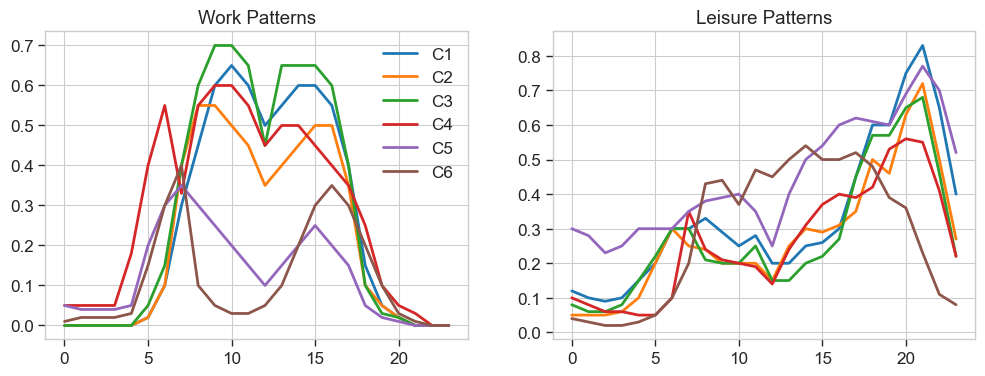

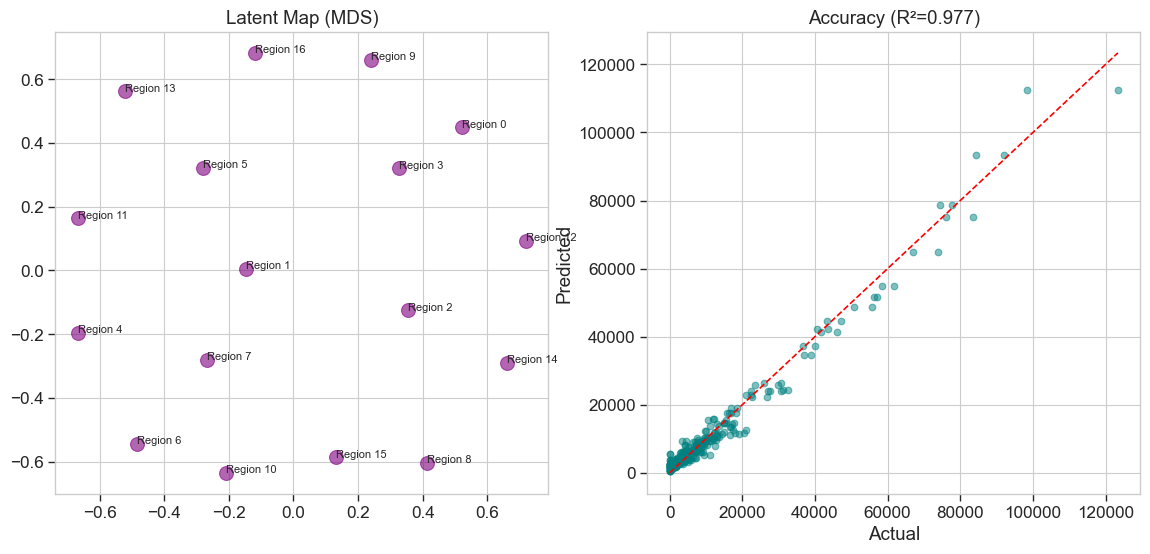

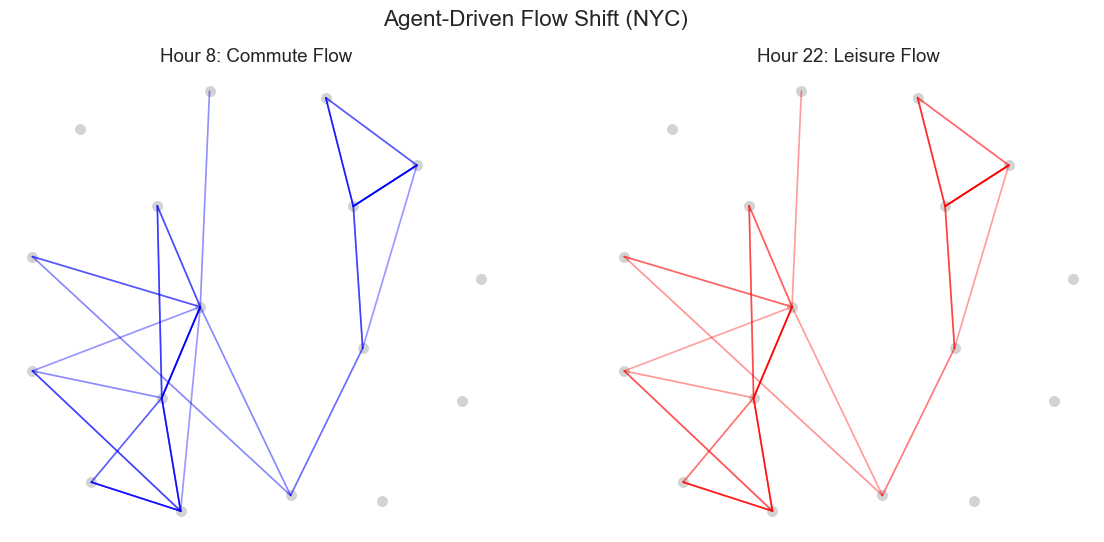


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:05:50] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (d8d8fcc2-e056-4a96-91c6-61f96915a859): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:05:50] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (b05dca62-41cf-4aaa-aa5e-030a37e26de9): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "061", "state_fips": "

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:06:32] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To tackle this task, let's break it down into steps and analyze the given information.

### Step 1: Understand the Given Information

- **City:** NYC
- **Day:** Weekday
- **Hour:** 6
- **State:** Various states (NYC_1, NYC_2, NYC_3, NYC_4) with associated probabilities of being in a "sleep" state.

### Step 2: Analyze Cultural/Temporal Drivers

Given it's 6 AM on a weekday in NYC, we're at a time when people are typically waking up and preparing for their day. The fact that it's a weekday suggests that many people will be getting ready for work or school. The cultural/temporal drivers here include:

- The early morning hour indicates a transition from sleep to wakefulness.
- Weekdays are associated with work and school rou

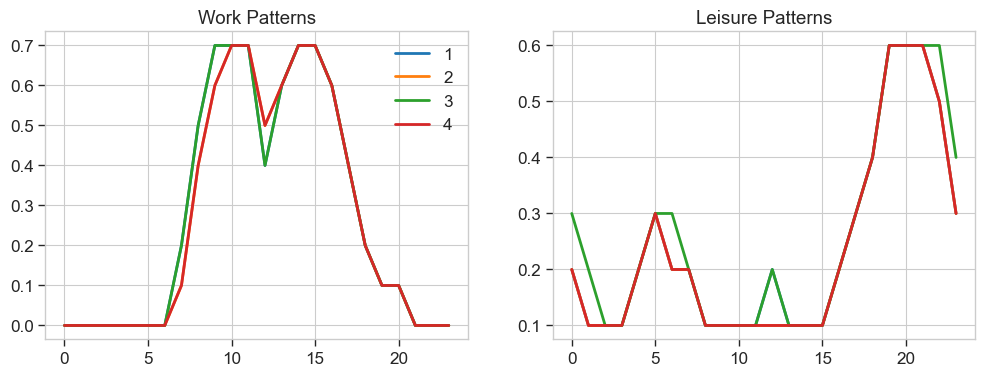

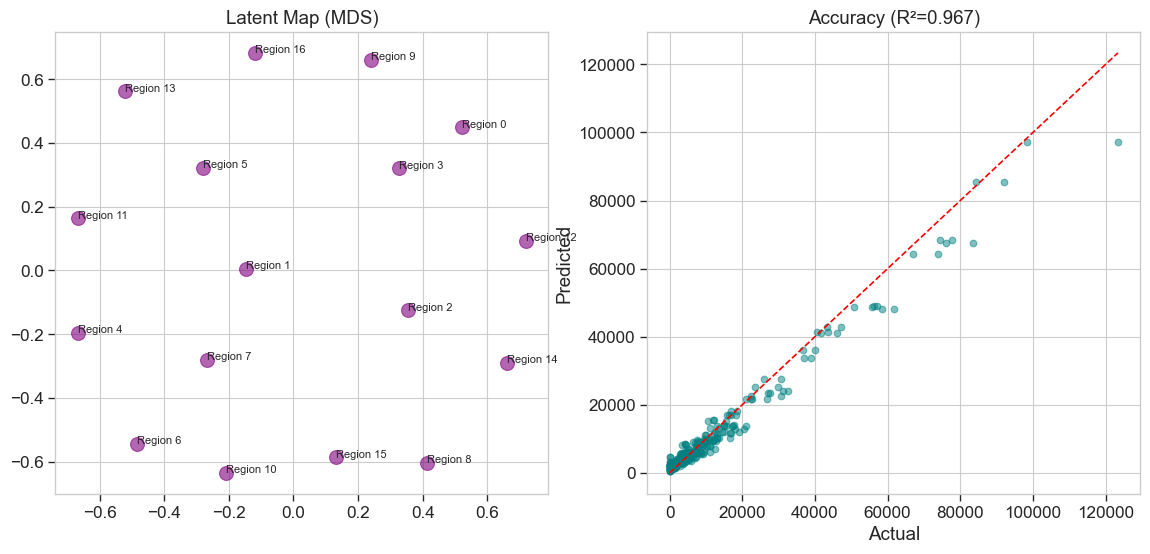

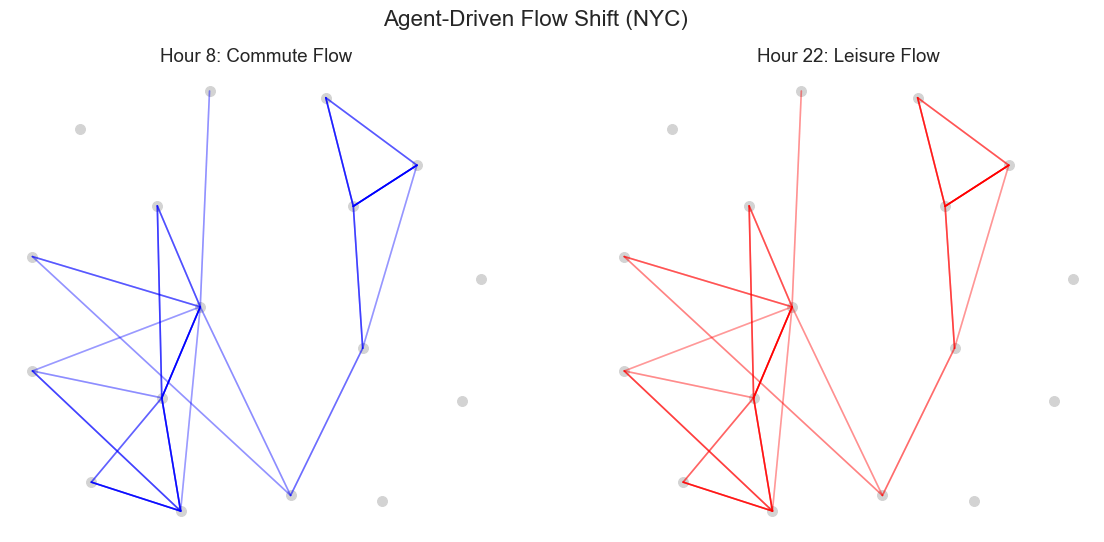


   🤖 MODEL: google.gemini-2.5-flash...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:08:49] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (f644bedc-ccbc-44d9-9c0a-d8ee5718dde2): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:08:52] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (7767882f-b1a5-42c5-a279-8bd86a47d452): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "061", "state_fips": "36", "clusters": [{"cluster_id": 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:11:32] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At 6 AM on a weekday in NYC, the dominant activities are sleep and the very beginning of the morning commute. A significant portion of 'NYC_young_urban_professionals,' 'NYC_established_families,' 'NYC_older_adults_retirees,' and 'NYC_affluent_urbanites' are still sleeping or just waking up, contributing to a high 'home' force. However, the 'NYC_diverse_working_class' shows a notable percentage already at work (0.30), indicating a strong early commute force for essential workers and those with early shifts. Leisure activities are minimal at this hour.",
  "forces": {
    "commute": 0.5,
    "leisure": 0.1,
    "home": 0.7
  }
}
```

-----------------------------------------------------------------------------

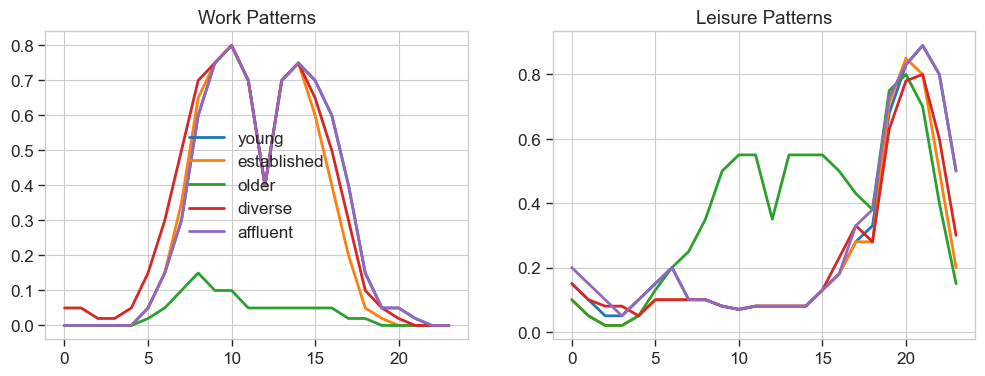

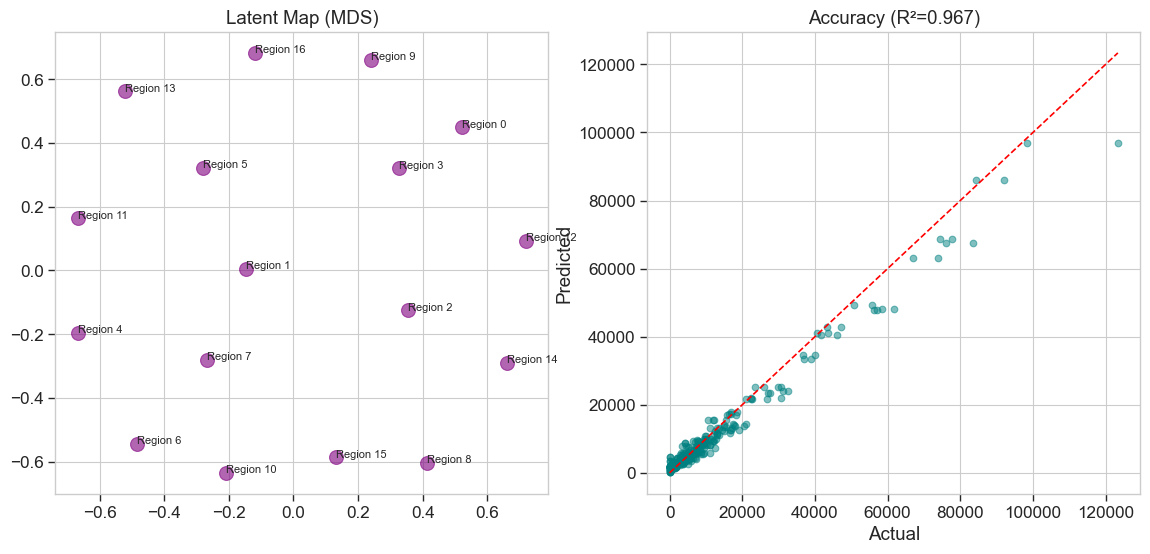

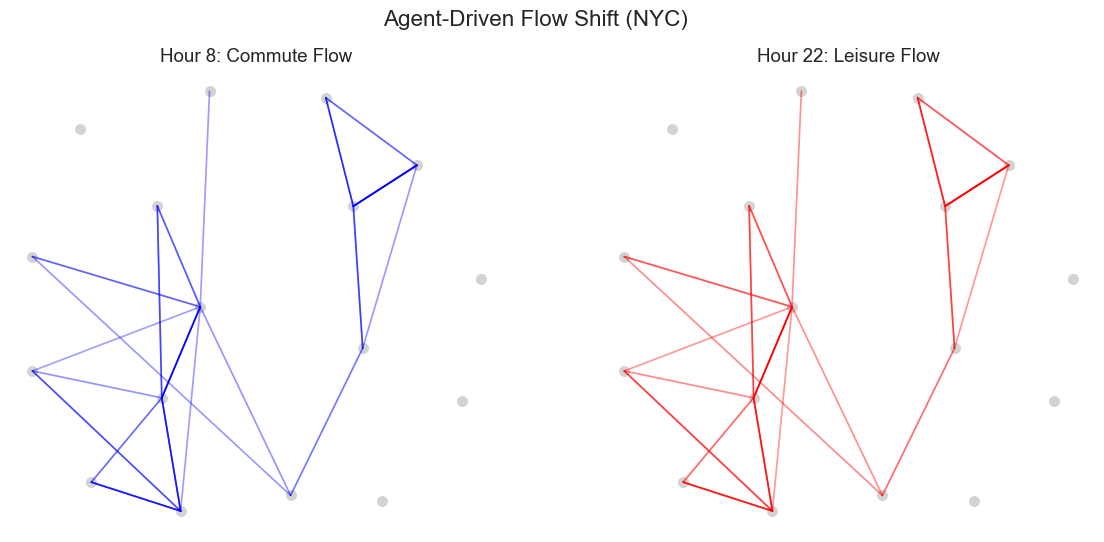


   🤖 MODEL: xai.grok-3-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:16:38] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (38610f31-5001-4ff8-9ad7-afd64cb06431): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:16:48] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (bcec0006-d852-4c5f-8ab3-6d9e2ea345c3): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "061", "state_fips": "36", "clusters": [{"cluster_id": "C1", "population_count"

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:20:27] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "At 6 AM on a weekday in NYC, temporal drivers indicate the early morning transition from sleep to daily routines, with many residents waking up and preparing for the day. Culturally, NYC has a strong work-oriented environment, leading to early commutes for jobs in finance, services, and other sectors. The provided state shows varying sleep probabilities across categories (average sleep probability of 65%), suggesting that while a significant portion of the population is still at home or asleep, others are beginning to engage in commute-related activities. Leisure activities are minimal at this hour due to the early time and weekday context. Therefore, the home force is high based on the average sleep probability, commute fo

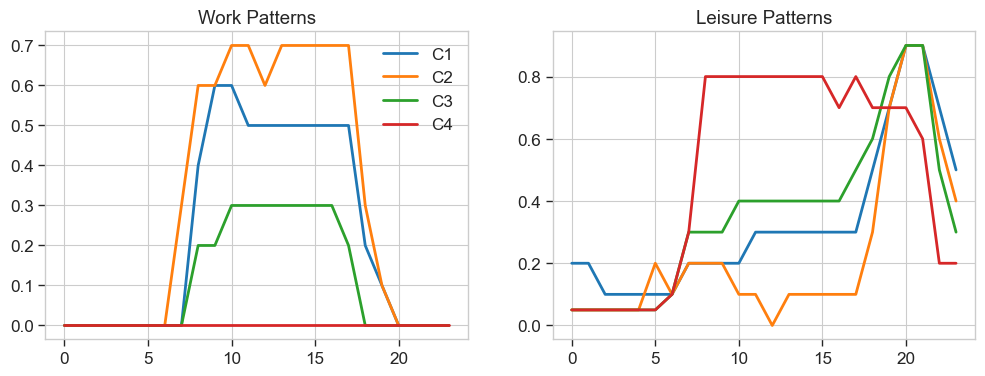

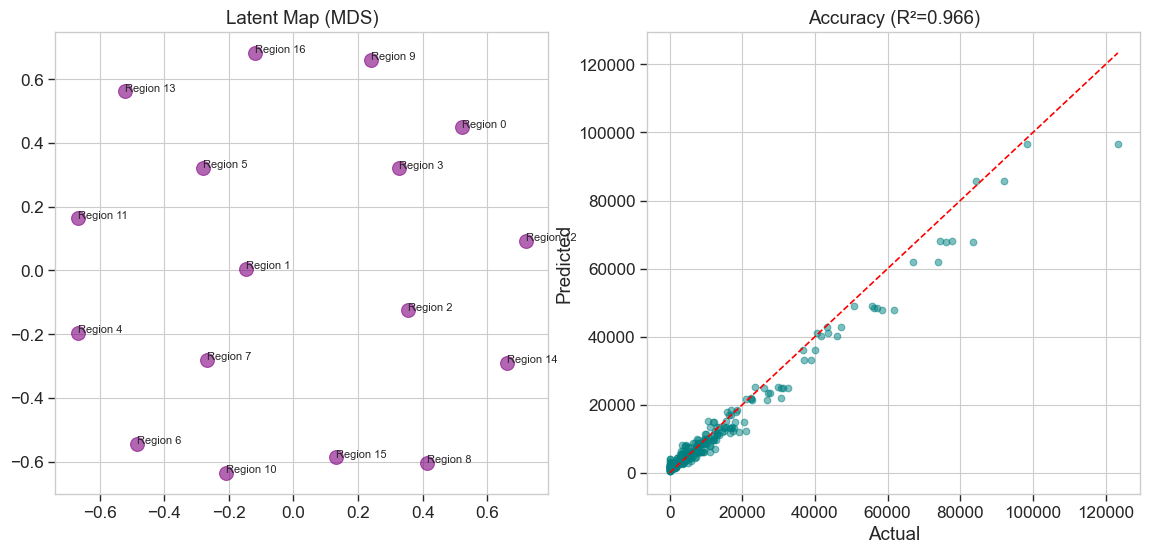

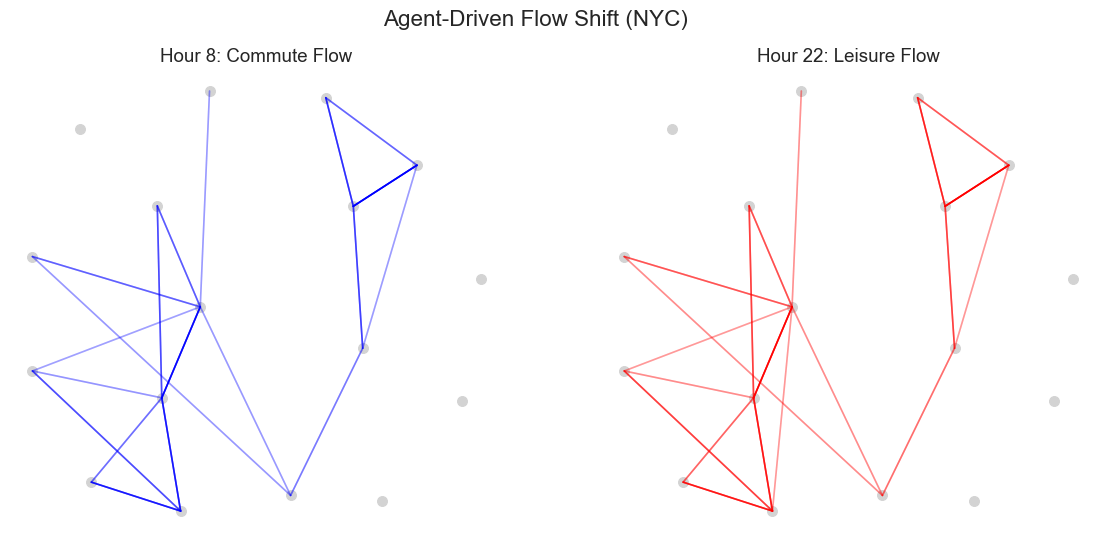


🏙️  STARTING BENCHMARK: Las Vegas

   🤖 MODEL: openai.gpt-5-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:23:31] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (6f238662-2914-4031-a230-5c7c75852961): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:23:48] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (4926f219-7977-4d07-8365-b26eb451f637): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "003", "state_fips": "32", "clusters":

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:29:24] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{"reasoning":"At 06:00 on a weekday in Las Vegas the dominant temporal driver is the morning shift into work: young professionals, suburban families and affluent households have substantial probabilities of leaving for work, and a large local service workforce starts early to staff hotels, casinos and food/beverage operations. Cultural drivers amplify this: Vegas’s tourism- and hospitality-led economy produces many early shift commutes (back-of-house staff, kitchen/cleaning crews, early hospitality logistics) while retirees skew toward morning leisure (walks, errands) and students still show elevated home/sleep presence. Overall this produces a strong commute signal, a smaller but non-negligible leisure pulse from retirees and visitors sta

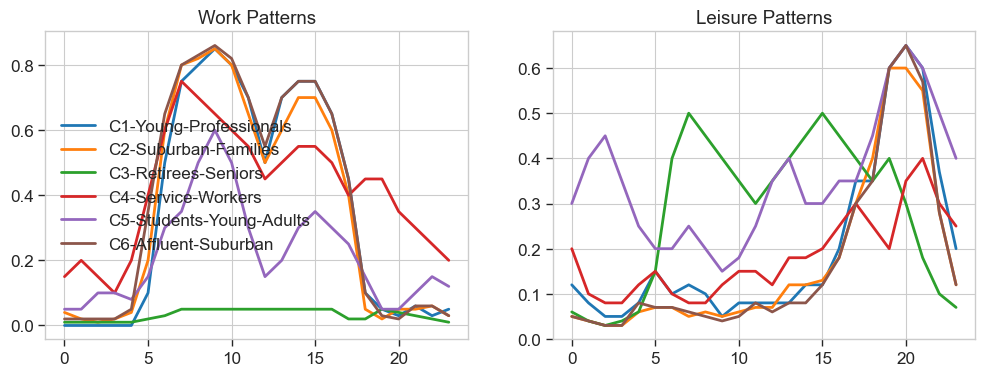

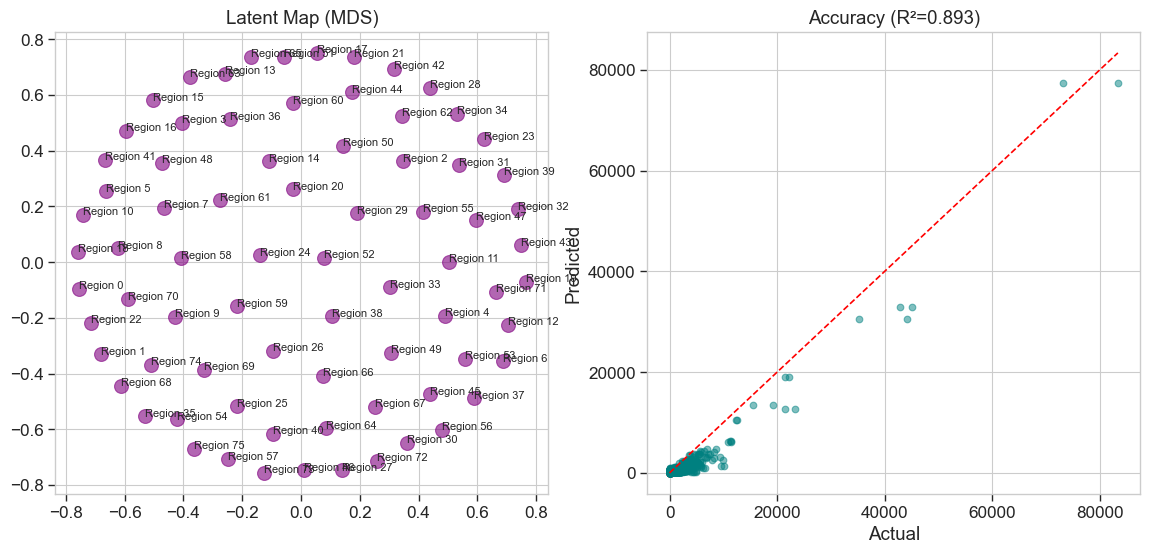

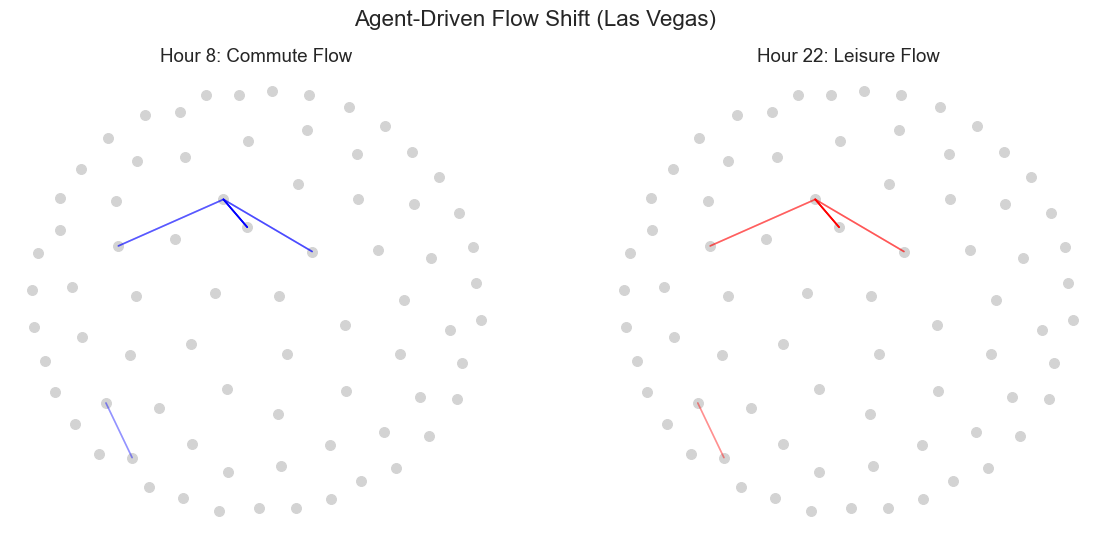


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:32:12] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (665fae2d-7754-4793-9c30-5df05d443b62): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:32:13] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (04f757dd-383a-414a-a4cd-d32c6452859e): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "003", "state_fips": "

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:33:18] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To analyze the given scenario and output the required JSON, let's break down the information and the task.

1. **City and Time**: Las Vegas, Weekday, Hour 6.
   - Hour 6 implies early morning, just after sunrise.

2. **State**: The state of Las Vegas is described with four different identifiers (Las Vegas_1, Las Vegas_2, Las Vegas_3, Las Vegas_4) and their respective states are all related to "sleep" with varying probabilities.

3. **Task**:
   - Analyze cultural/temporal drivers: This involves understanding how the time of day, day of the week, and cultural context influence mobility.
   - Output 3 'Mobility Forces': These are commute, leisure, and home, represented as floats between 0.0 and 1.0.

### Analysis

- **Cultur

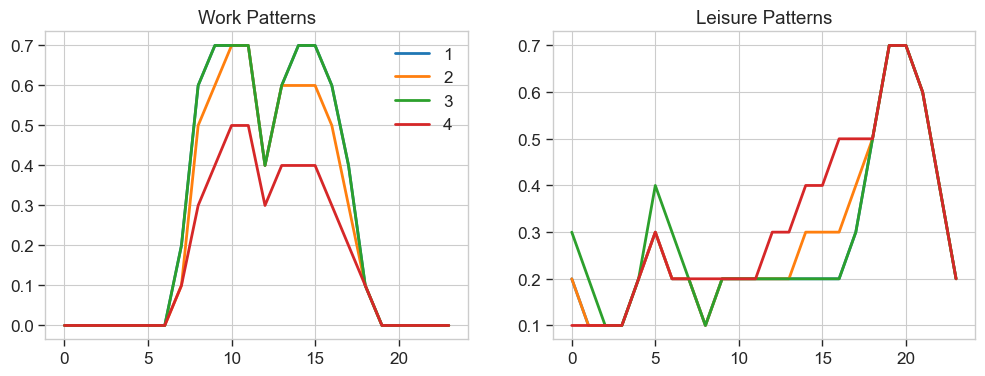

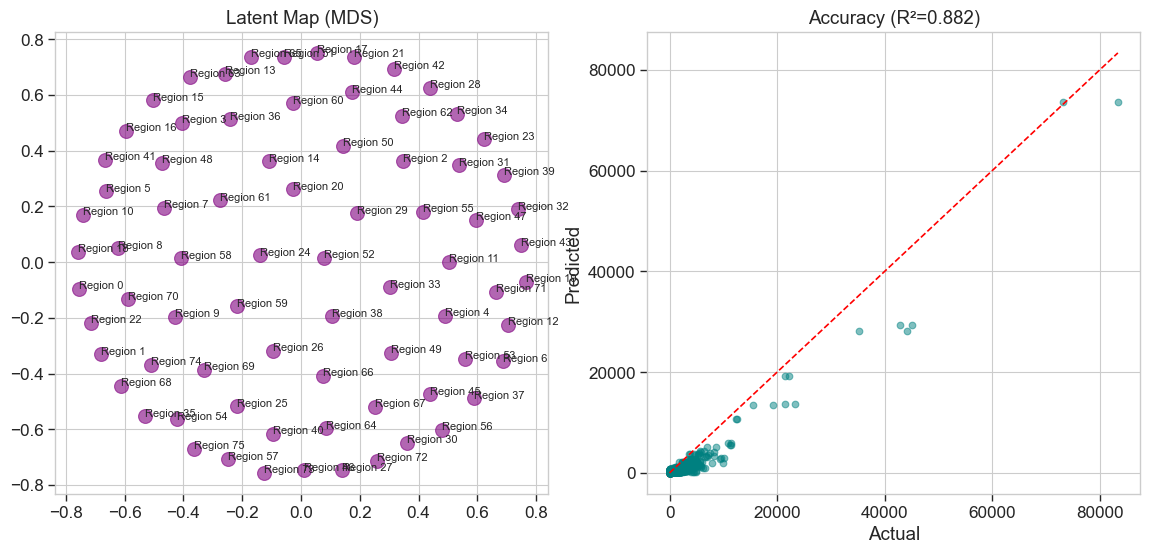

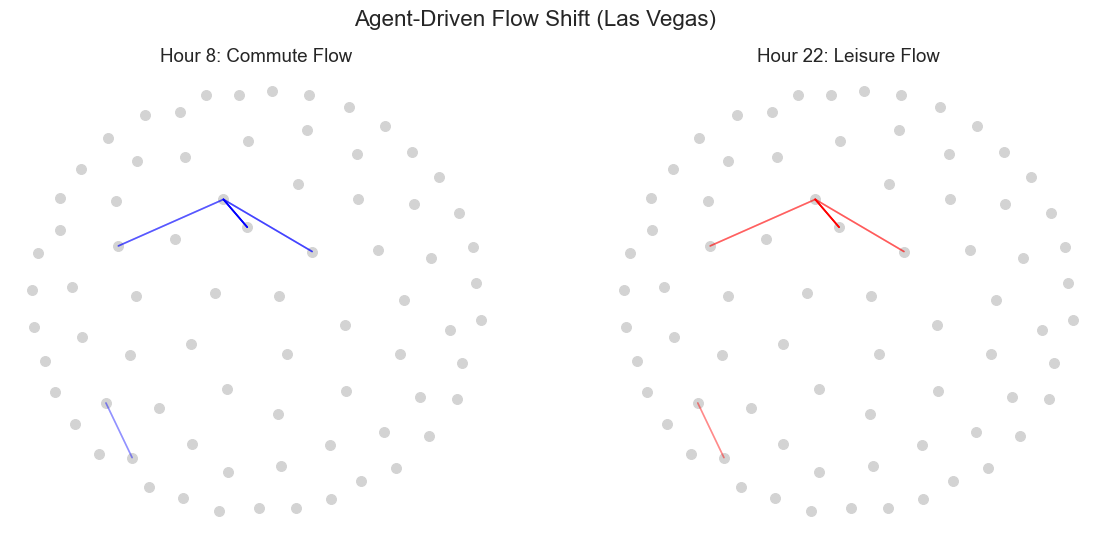


   🤖 MODEL: google.gemini-2.5-flash...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:35:41] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (ba26d0ea-f445-46cd-a937-cdab210c21d6): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:35:43] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (76bd5b61-677f-4c5a-a50c-13b73fb433e9): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "003", "state_fips": "32", "clusters": [{"cluster_id": 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:41:28] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "It's 6 AM on a weekday in Las Vegas. The primary temporal driver is early morning, where a significant portion of the population is still asleep, as indicated by sleep percentages ranging from 40% to 50% across all segments. For those awake, it's typically a time for waking up and preparing for the day at home. While Las Vegas operates 24/7, leading to some early shift work (especially in hospitality, where C4 shows a slightly lower sleep percentage), the overall population's activity is still largely centered around the home. Commute activity is starting to pick up for early workers but is far from its peak, and leisure activities are minimal during this hour.",
  "forces": {
    "commute": 0.40,
    "leisu

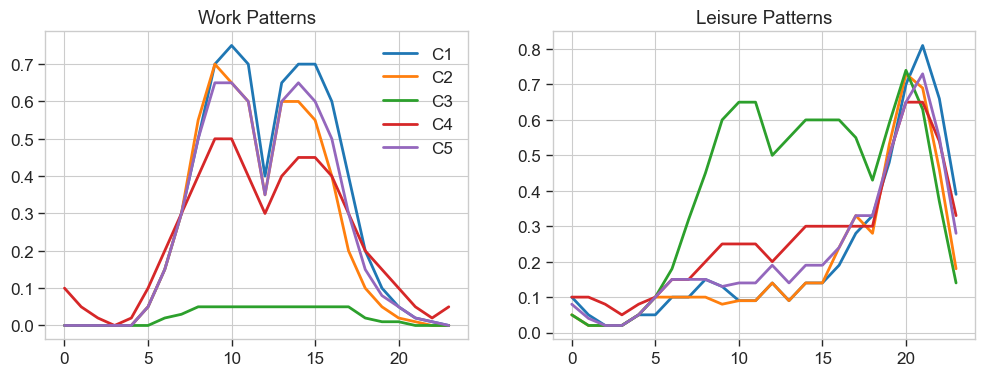

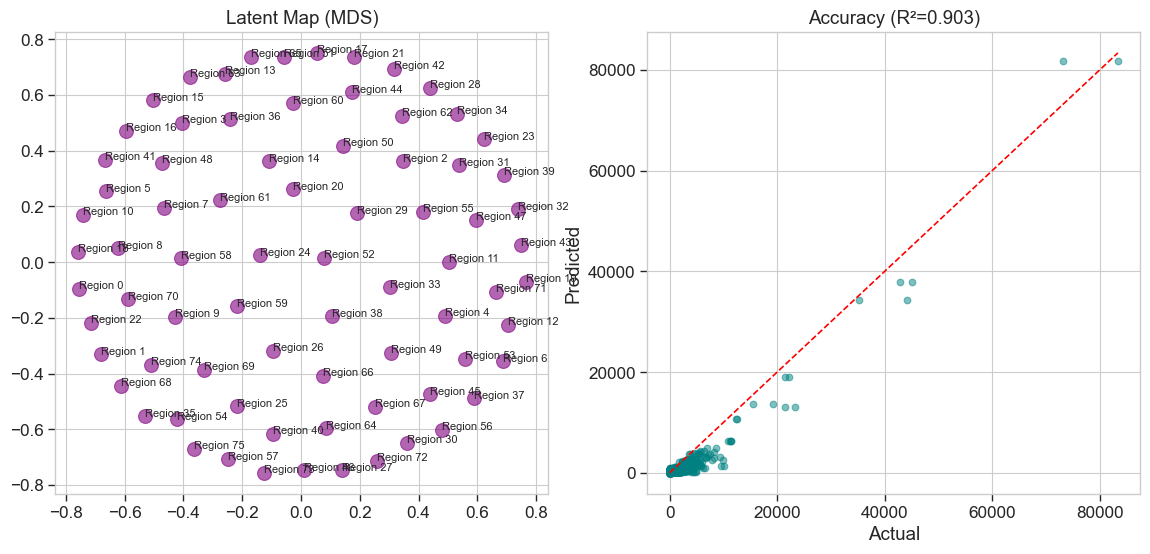

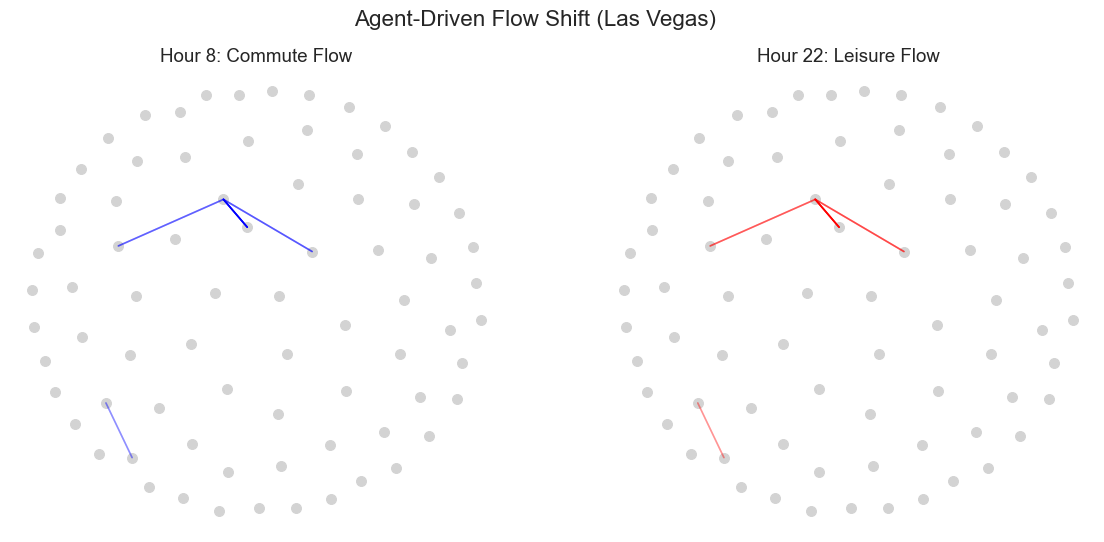


   🤖 MODEL: xai.grok-3-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:45:15] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (62d8f288-58a3-44ed-98ff-b42ed5d7c28d): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:45:22] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (584aee8c-3bff-4bc9-9ef1-b6f5388f4541): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "003", "state_fips": "32", "clusters": [{"cluster_id": "C1", "population_count"

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:48:07] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "In Las Vegas at 6 AM on a weekday, temporal drivers indicate the early morning transition from sleep to daily routines, with low overall activity as people are typically resting or preparing for the day. Culturally, while Las Vegas is known for its 24/7 entertainment and tourism, this time sees minimal leisure due to the focus on recovery from nightlife or standard work preparation. Given that all population clusters are in a sleep state with 100% probability, mobility is heavily influenced by home-centric behaviors, resulting in low drives for commuting and leisure, and a strong drive to remain at home.",
  "forces": {
    "commute": 0.10,
    "leisure": 0.05,
    "home": 0.90
  }
}

---------------------------------------

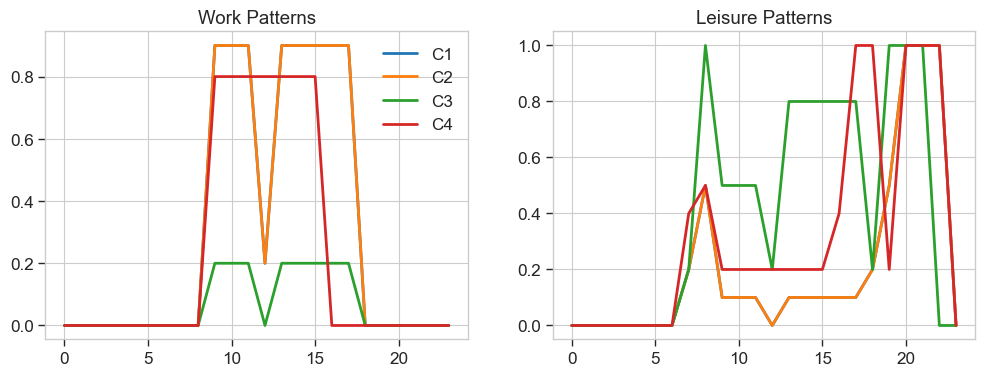

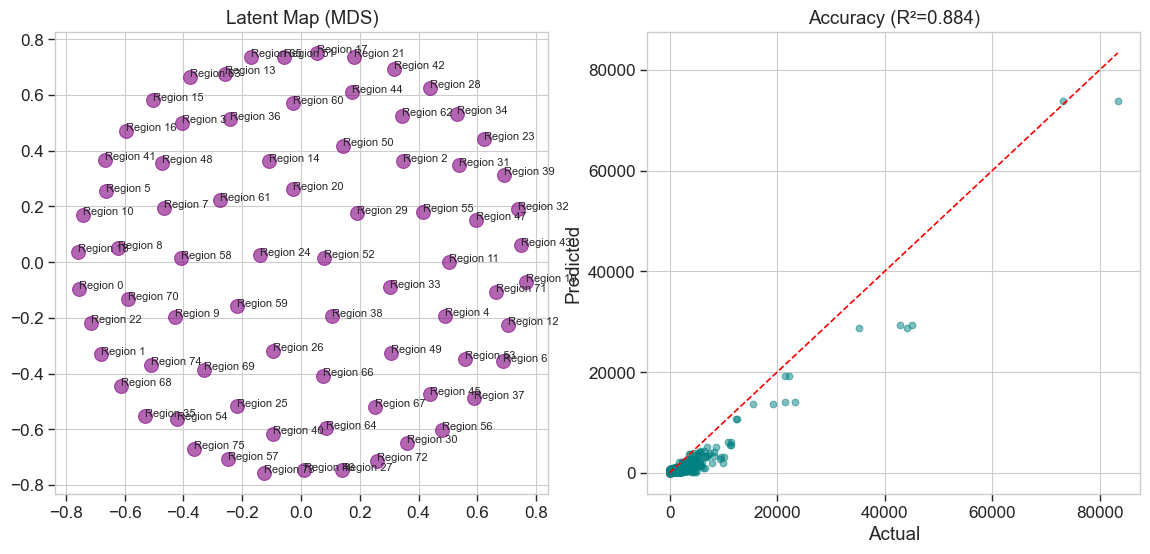

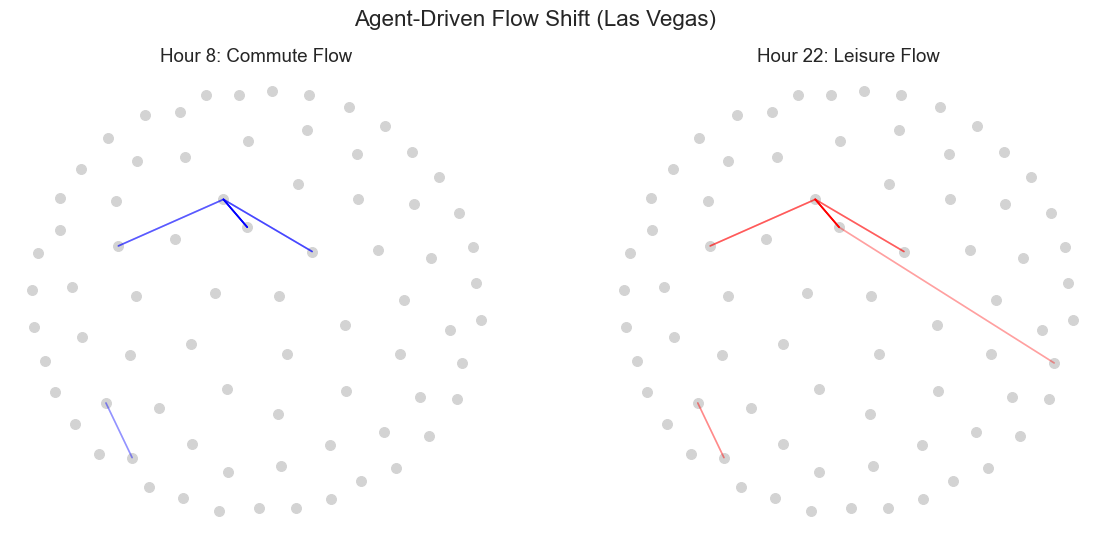


🏙️  STARTING BENCHMARK: San Francisco

   🤖 MODEL: openai.gpt-5-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:50:57] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (7e9de717-128d-4a81-87bf-c17d6d378d5f): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 17:51:06] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (486bf483-d560-4588-a734-3f002d5ad9b0): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "075", "state_fips": "06", "cluste

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 17:57:18] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{"reasoning":"6 AM on a weekday in San Francisco is an early-morning transition period: a substantial slice of service workers (C3: 60% at work) and many students/young professionals and families already up and travelling for shifts and school, while a large fraction of tech pros remain sleeping or starting later. Cultural/temporal drivers include later average start times for many tech roles (reducing peak commute at this hour), a non-negligible early-shift workforce and school drop-offs that boost morning trips, and an active retiree population doing short local outings. Together these produce a strong but not peak commuting force, moderate at-home presence (people still in bed or preparing to leave), and low leisure travel at this hour.

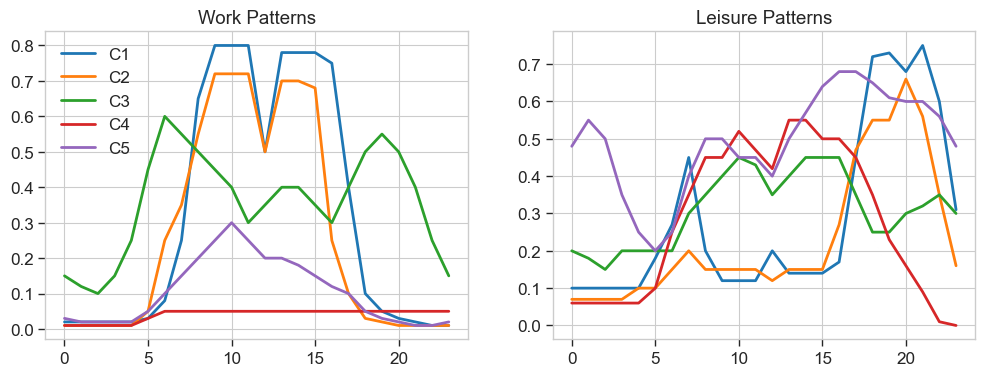

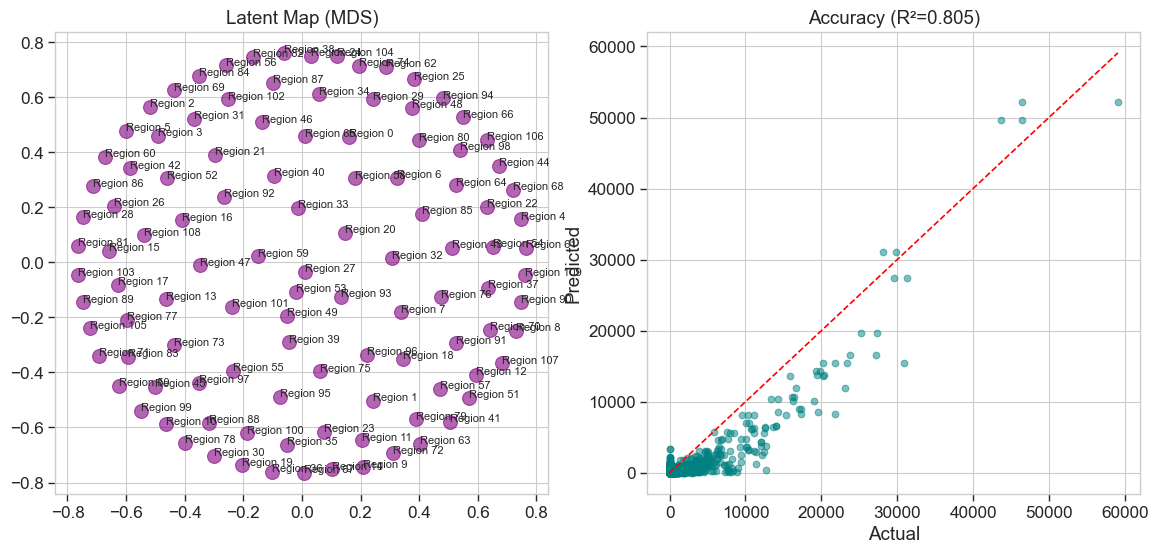

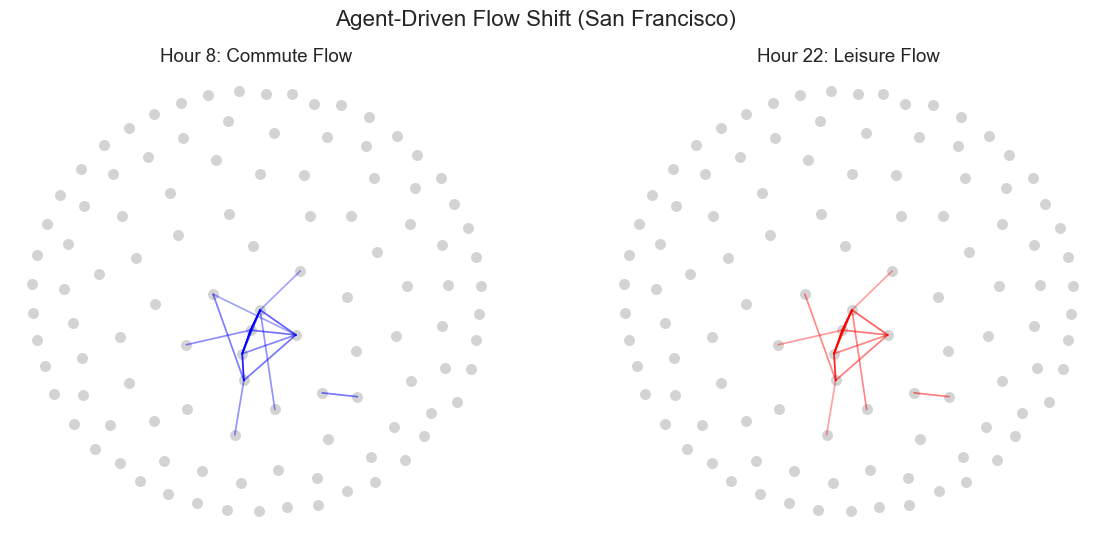


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:00:11] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (0e204f5f-e134-4411-a203-5bf69c1ff581): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:00:12] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (6c82b73f-3d62-4b71-ab7c-25b8fea6ef89): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "075", "state_fips": "

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 18:00:51] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To tackle this task, let's break down the information provided and analyze it step by step.

1. **City, Weekday, Hour 6**: The city is San Francisco, it's a weekday, and the hour is 6. Given that it's hour 6 on a weekday, it implies early morning, likely around sunrise or just before. San Francisco is known for its vibrant culture and diverse population.

2. **State: San Francisco_1: sleep (0.50); San Francisco_2: sleep (0.50); San Francisco_3: sleep (0.40); San Francisco_4: sleep (0.60)**: This information suggests that different districts or areas within San Francisco (let's assume San Francisco_1 through San Francisco_4 represent different districts or aspects of the city) are in a state of sleep with varying probabilit

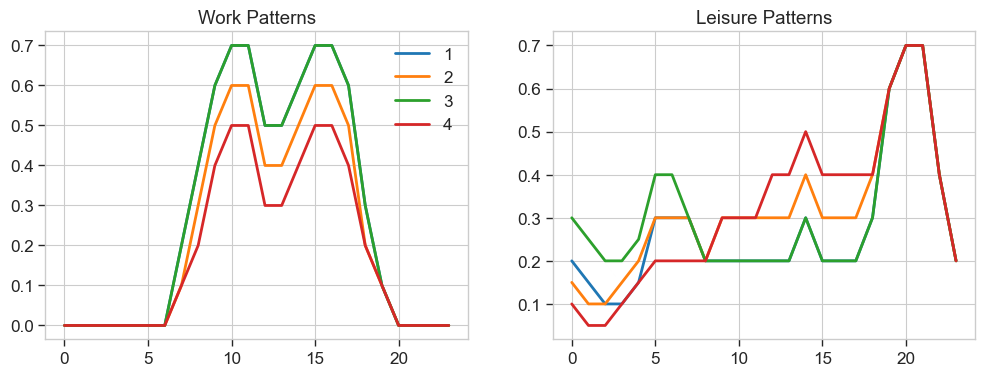

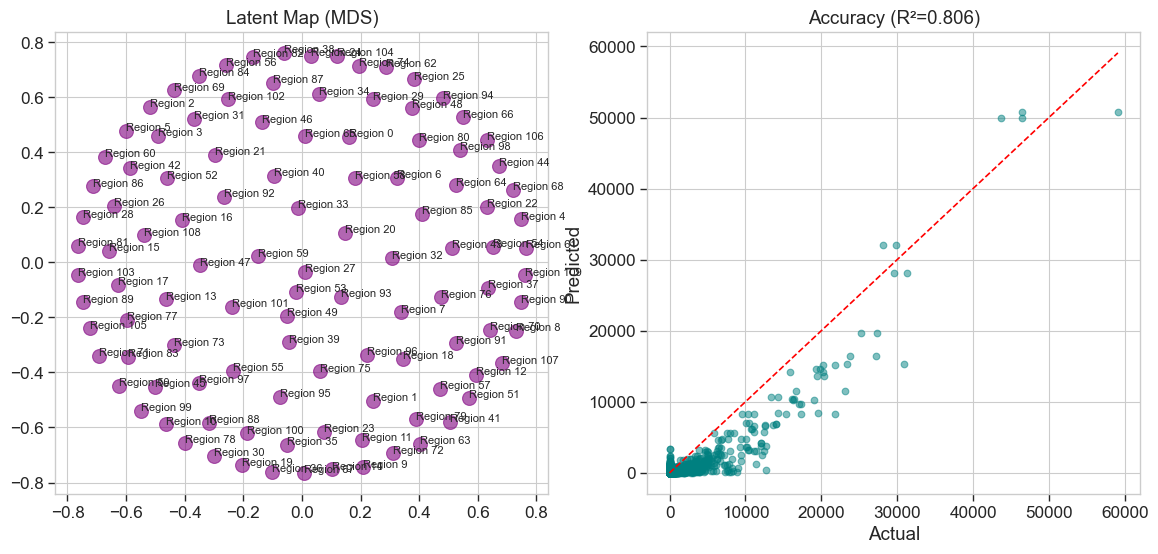

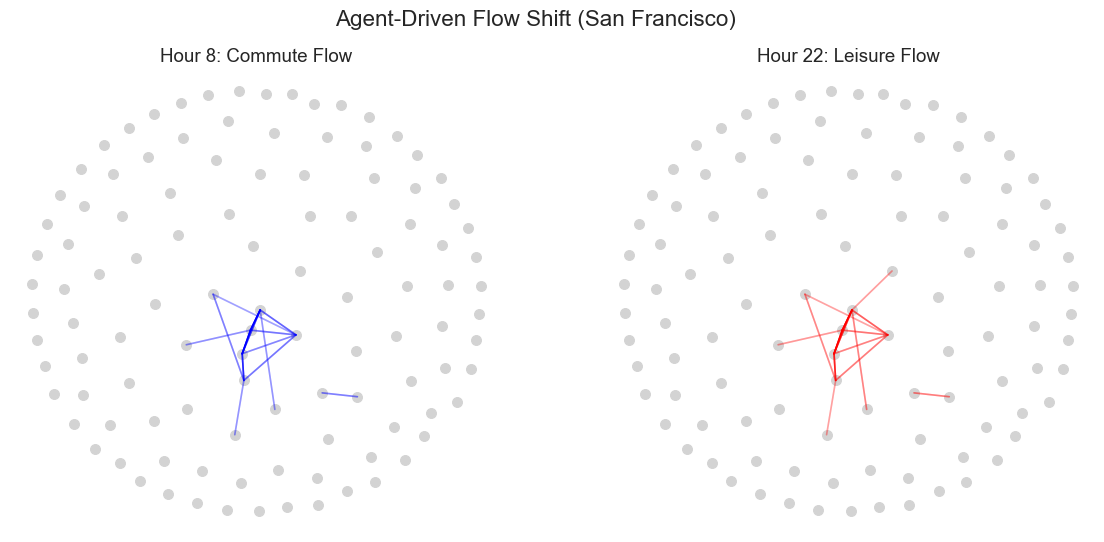


   🤖 MODEL: google.gemini-2.5-flash...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:03:09] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (9baba38a-8bc5-4878-8112-656a76f19cba): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:03:13] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (636d2477-0058-4d7b-8a80-619136cf4036): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "075", "state_fips": "06", "clusters": [{"cluster_id": 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 18:05:40] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At 6 AM on a weekday in San Francisco, a significant portion of the population, particularly Students and Young Creatives (80% sleep) and Established City Dwellers/Seniors (40-45% sleep), are still at home, either sleeping or preparing for the day. This results in a very high 'home' force. However, the 'Diverse Working Class' shows 30% already at 'work', indicating that the morning commute is actively underway for early-shift workers, contributing to a substantial 'commute' force. Leisure activities are generally very low at this early hour on a weekday, only catering to specific early risers.",
  "forces": {
    "commute": 0.65,
    "leisure": 0.15,
    "home": 0.85
  }
}
```

------------------------------

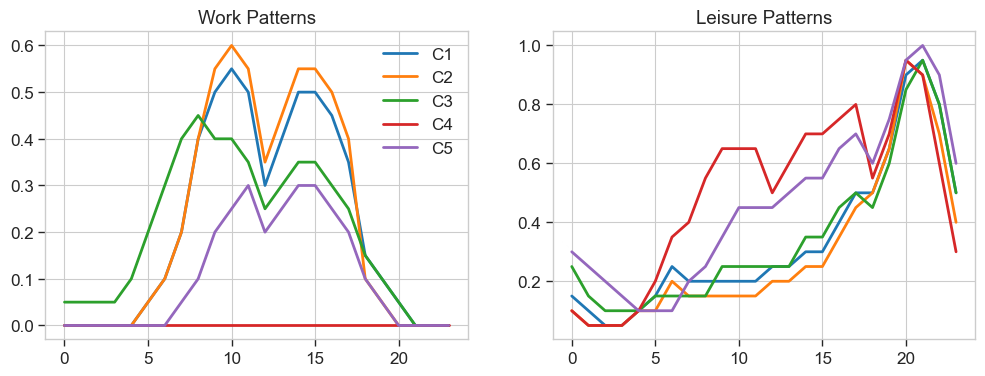

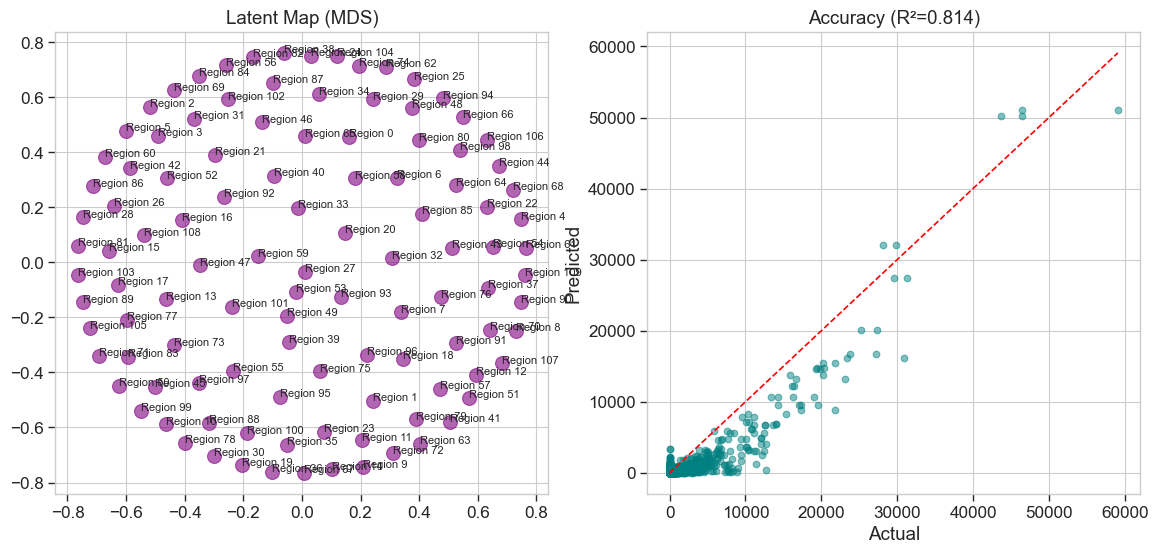

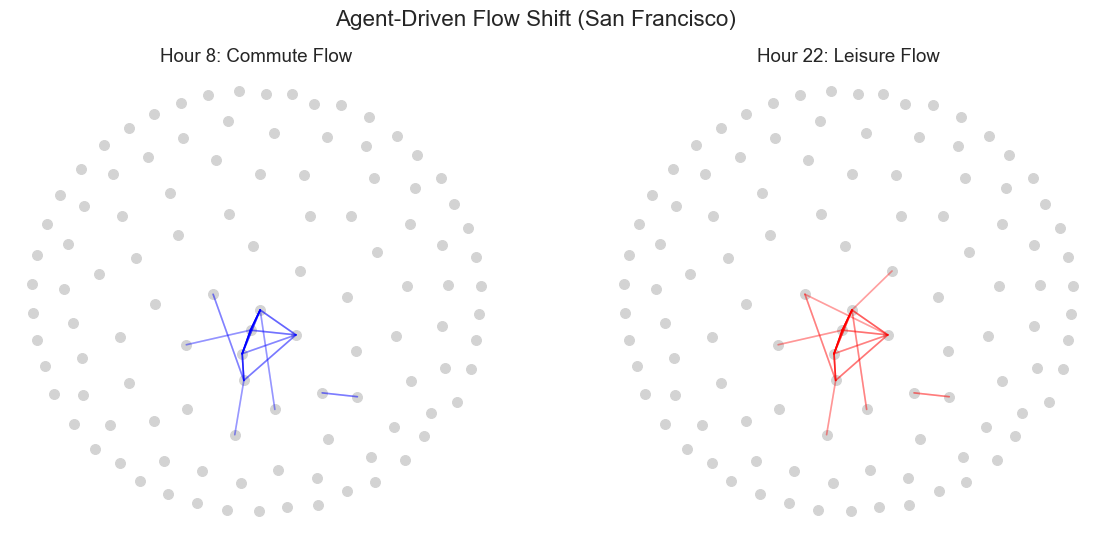


   🤖 MODEL: xai.grok-3-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:21:30] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (6e8e2946-34fa-490b-a460-72392c8c1eb8): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:21:45] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (cd486fbe-0110-44cb-bd03-fad2f77a6a28): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "075", "state_fips": "06", "clusters": [{"cluster_id": "c1", "population_count"

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 18:29:35] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "At 6 AM on a weekday in San Francisco, temporal drivers such as early morning hours typically involve low mobility, with many people still at home or just beginning their day. Culturally, San Francisco's urban and tech-driven lifestyle may include early risers for work or fitness, but the provided state data shows high sleep probabilities across clusters (average 71%), indicating that most individuals are likely at home, sleeping or resting. This results in a strong home force, while commute is moderately low as rush hour has not peaked, and leisure is minimal due to the early weekday timing.",
  "forces": {
    "commute": 0.30,
    "leisure": 0.10,
    "home": 0.80
  }
}

---------------------------------------------------

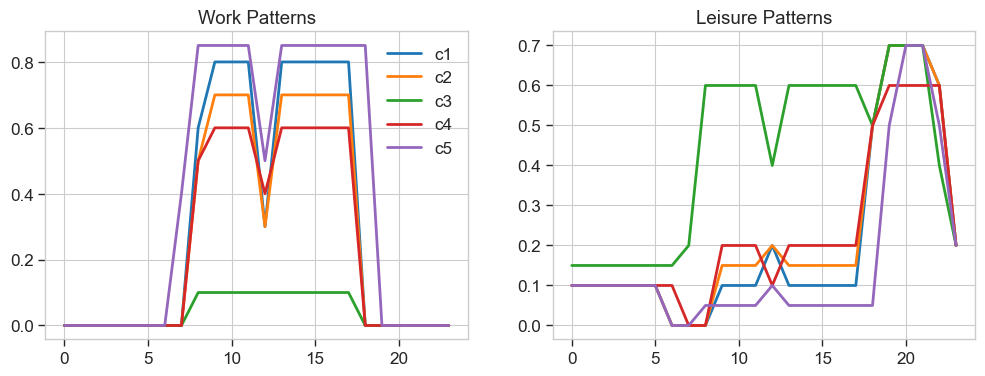

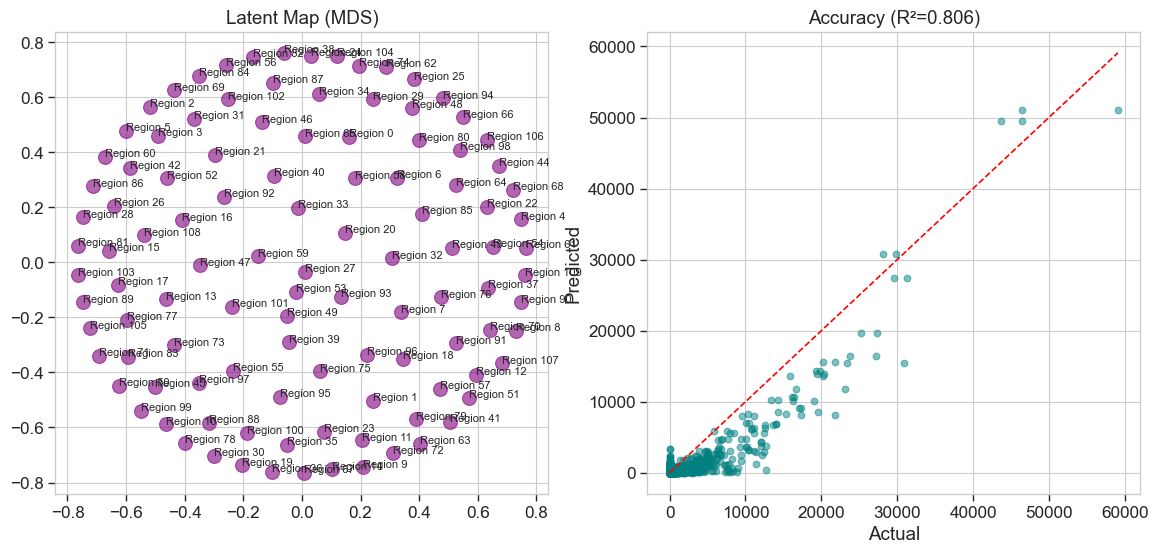

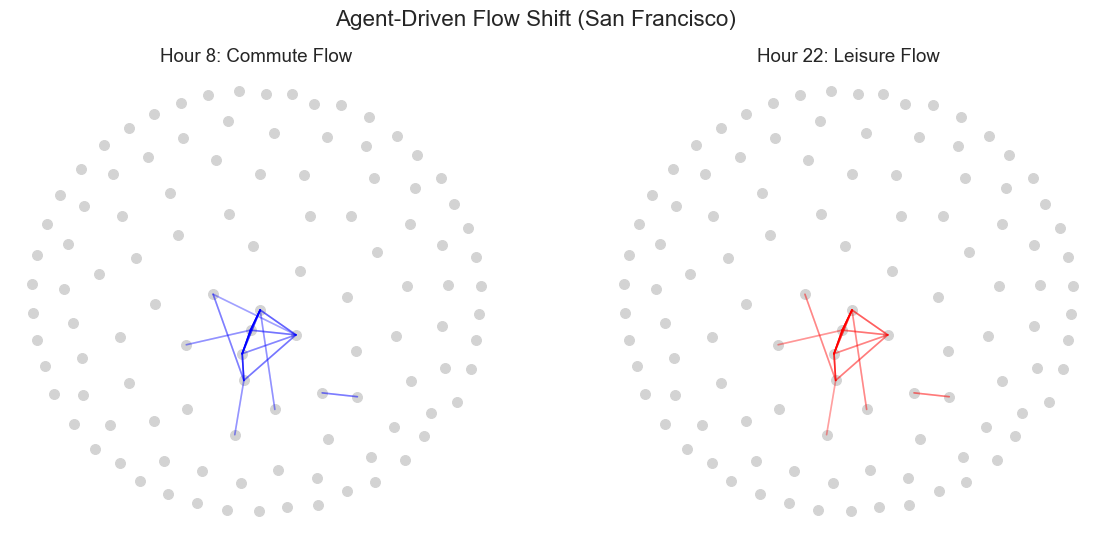


🏙️  STARTING BENCHMARK: Minneapolis

   🤖 MODEL: openai.gpt-5-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:52:48] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (3583375c-28eb-4df6-b517-348c3feec709): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 18:53:01] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (0fc19aa3-4430-45ab-97bc-8dc87923d725): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "053", "state_fips": "27", "clusters

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 18:57:58] {704} WARNING - Model openai.gpt-5-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{"reasoning":"I treated each segment activity weight as a population share at 06:00 and normalized them to estimate the dominant mobility state. Sum of provided weights = 2.10, of which work-flagged weights total 1.45 and sleep-flagged weights total 0.65. That yields ~69% of the sampled population engaged in outbound/commute activity and ~31% still at home/sleeping. Temporal drivers: 06:00 on a weekday is the leading edge of the morning commute—early-shift and working-class populations (Northside, suburban families, mixed-income transit neighborhoods, downtown professionals) push up outbound mobility. Cultural drivers: university students and older retirees remain home/sleeping in larger fractions at this hour, suppressing leisure and disc

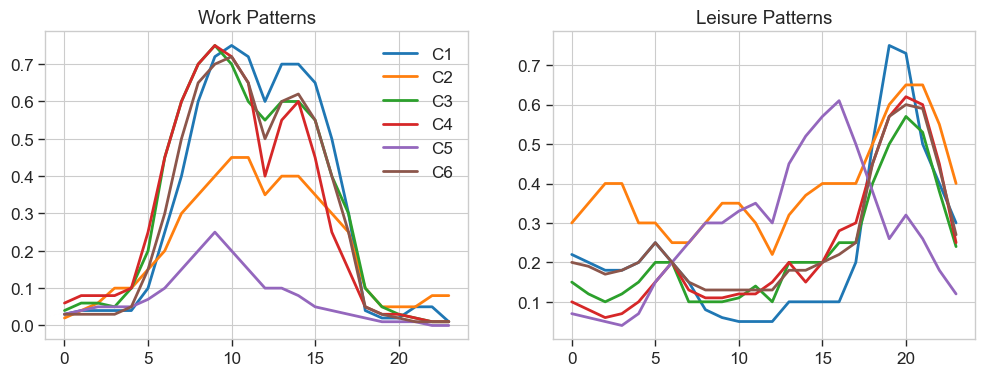

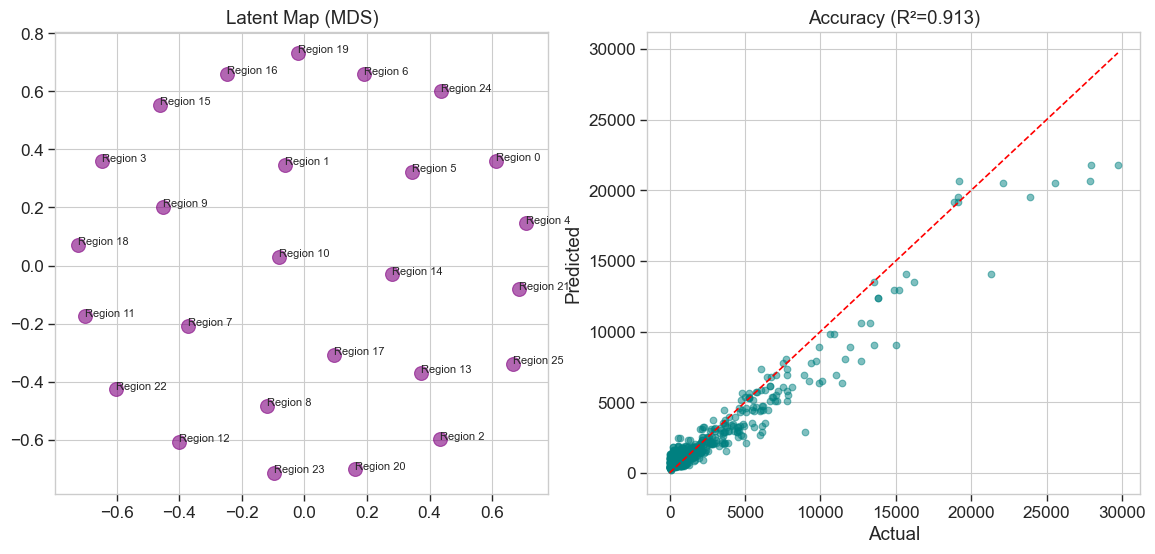

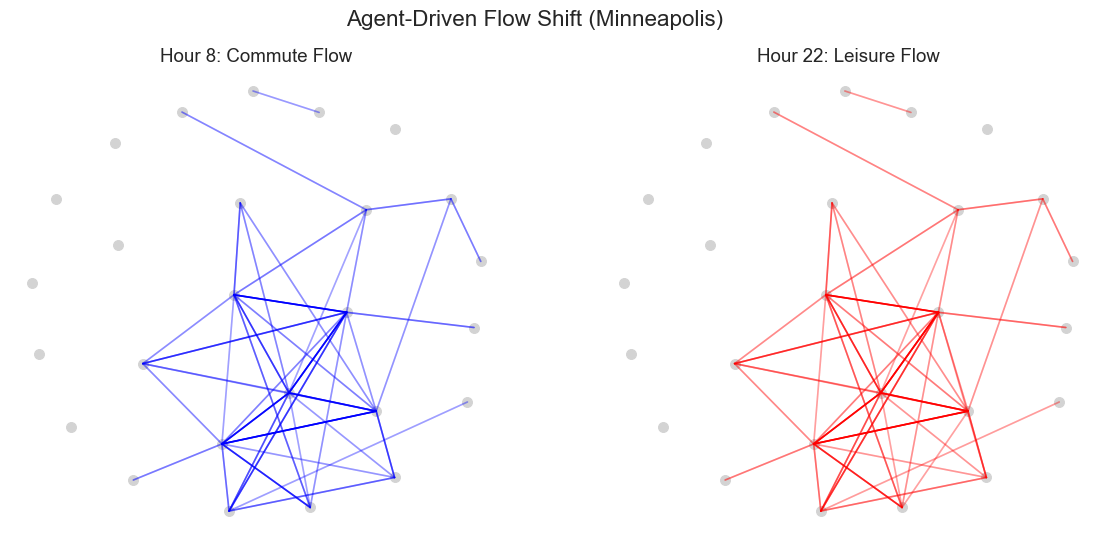


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 19:02:15] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (08c62bc7-e27d-409d-ae57-8d91d3ba4243): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 19:02:15] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (7bb056b4-5fc0-4398-95f7-9425f89a4c62): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "053", "state_fips": "

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 19:02:56] {704} WARNING - Model meta.llama-4-maverick-17b-instruct is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To tackle this task, let's break it down into steps and analyze the given information.

1. **Understanding the Context**: We're given a scenario set in Minneapolis on a weekday at hour 6 (early morning). The state of Minneapolis is described with four areas (Minneapolis_1 to Minneapolis_4) having different probabilities of being in a "sleep" state.

2. **Analyzing Cultural/Temporal Drivers**: 
   - The time is 6 AM on a weekday. Typically, this is a time when most people are still asleep or waking up.
   - The fact that it's a weekday suggests that the day is likely to be influenced by work or school schedules, with people expected to commute later in the morning.
   - The probabilities given for the different areas of Min

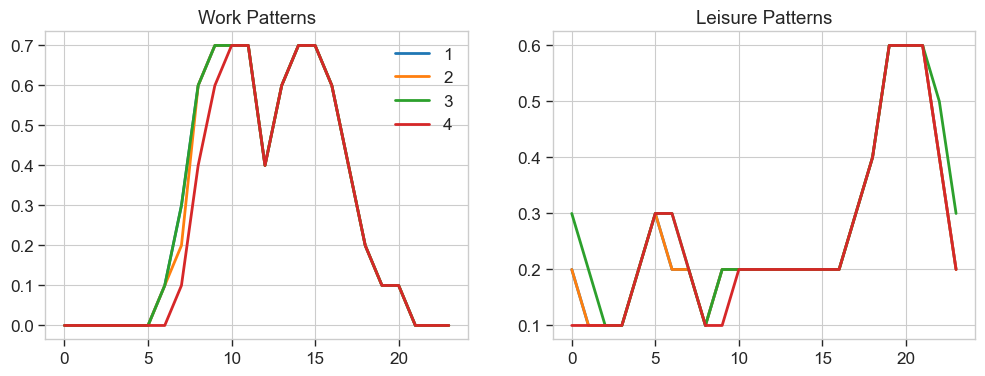

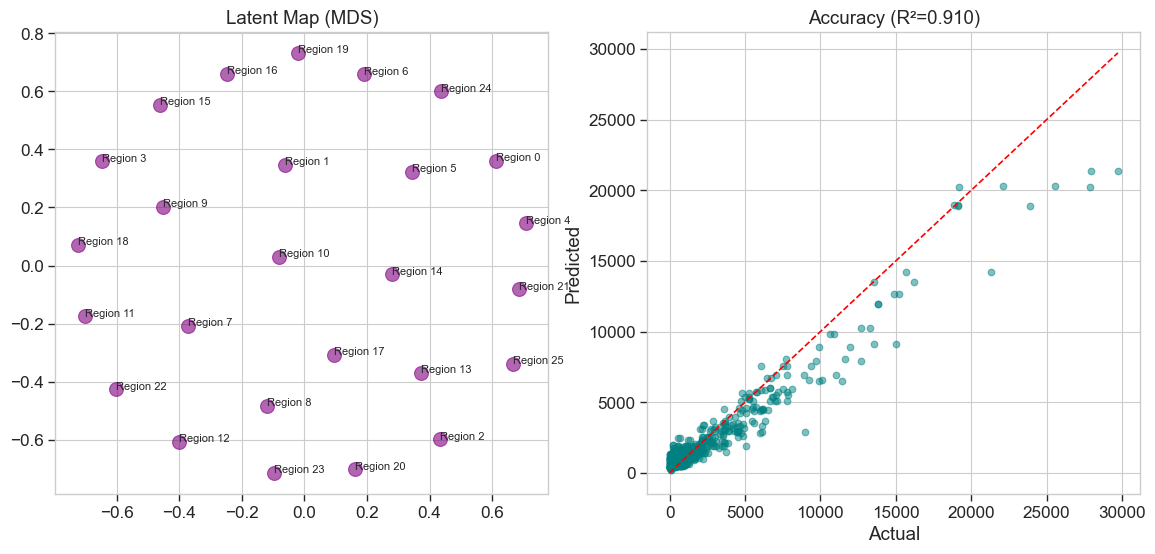

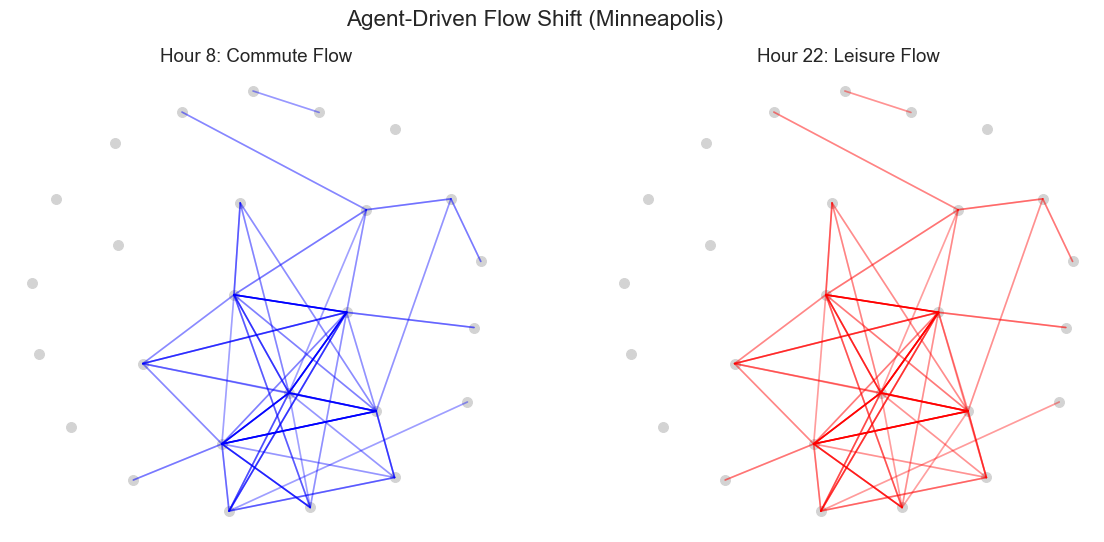


   🤖 MODEL: google.gemini-2.5-flash...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 19:06:09] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (39f24353-b4c9-4bce-a3da-8612659bb487): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 19:06:12] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (48d2948a-9c9f-4646-854d-528c17326011): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "053", "state_fips": "27", "clusters": [{"cluster_id": 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 19:09:48] {704} WARNING - Model google.gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At Hour 6 on a weekday in Minneapolis, the primary cultural and temporal driver is the very early morning, just before the main rush of daily activities. Most of the population is either still sleeping or just beginning to wake up and prepare for the day. Demographic data confirms this, showing a strong 'home' force due to high 'sleep' probabilities across established families, older adults, and the diverse working class. A moderate 'leisure' force is also present, primarily driven by young urban professionals and students, likely engaging in early morning personal activities (e.g., gym, coffee, personal time) before work or school. Although no explicit 'commute' activity is listed as dominant for any group,

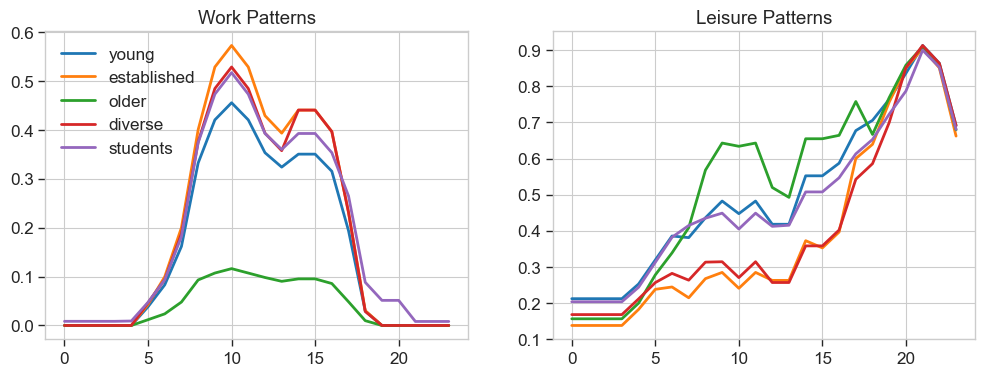

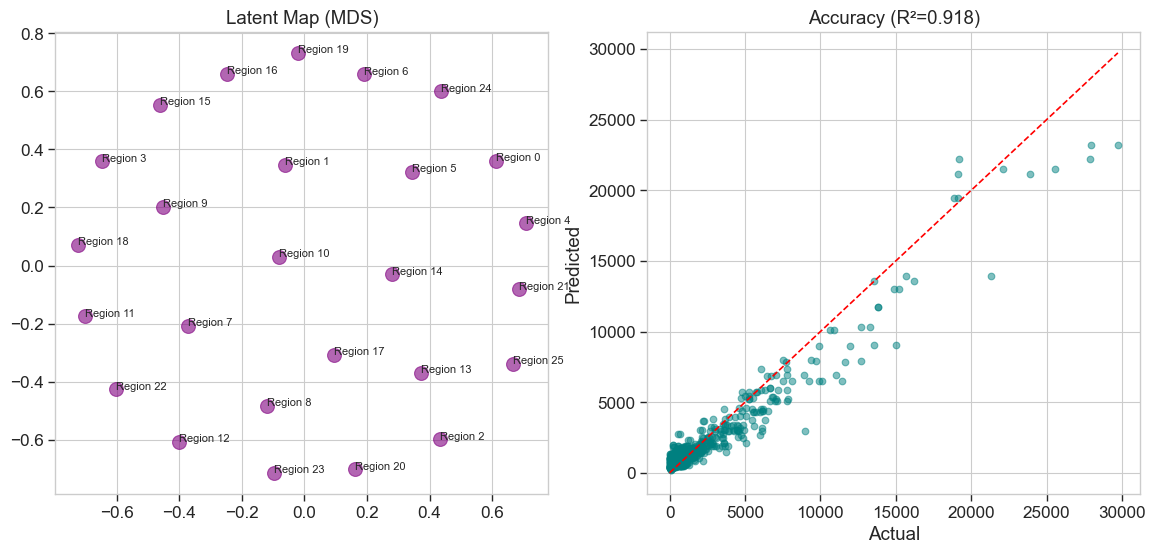

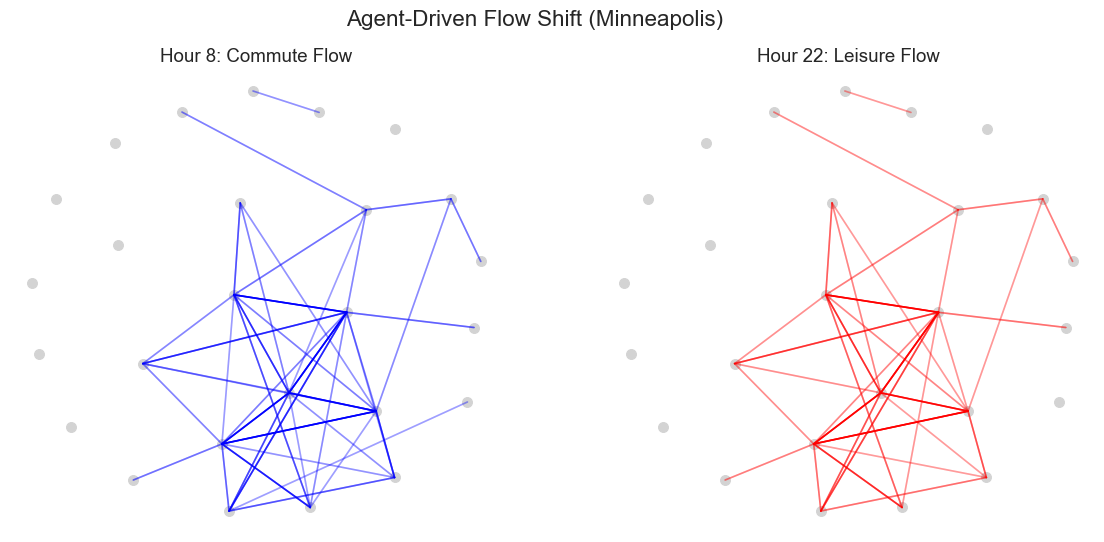


   🤖 MODEL: xai.grok-3-mini...
      ⏳ Generating Population...

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 19:22:36] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (7ce024f5-93c9-4347-a604-c32d1b2d07be): Maximum number of consecutive auto-replies reached

>>>>>>>> USING AUTO REPLY...
[autogen.oai.client: 03-30 19:22:47] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.

>>>>>>>> TERMINATING RUN (ed624abf-a166-47e5-af46-0c9142808df0): Maximum number of consecutive auto-replies reached
Runner (to Advocate):

{"stage": "population", "candidate_json": {"stage": "population", "county_fips": "053", "state_fips": "27", "clusters": [{"cluster_id": "C1", "population_count"

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 03-30 19:25:55] {704} WARNING - Model xai.grok-3-mini is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "At 6 AM on a weekday in Minneapolis, temporal drivers indicate an early morning period where sleep is still prevalent, with provided sleep probabilities averaging 0.525 across clusters, suggesting many residents are at home. Culturally, in an urban American city like Minneapolis, this time marks the beginning of daily routines, with commute activities starting to emerge but not at peak levels, while leisure is minimal due to the early hour and weekday context. Therefore, the home force is strong due to high sleep likelihood, commute force is moderate as people begin their day, and leisure force is low.",
  "forces": {
    "commute": 0.40,
    "leisure": 0.10,
    "home": 0.60
  }
}

-----------------------------------------

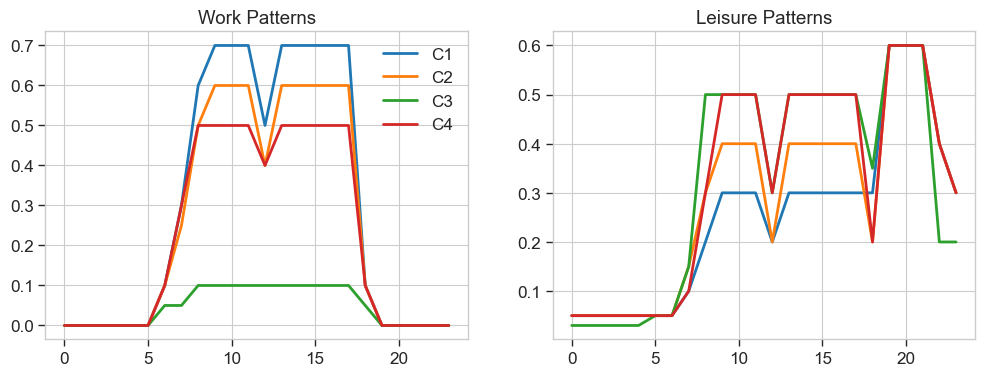

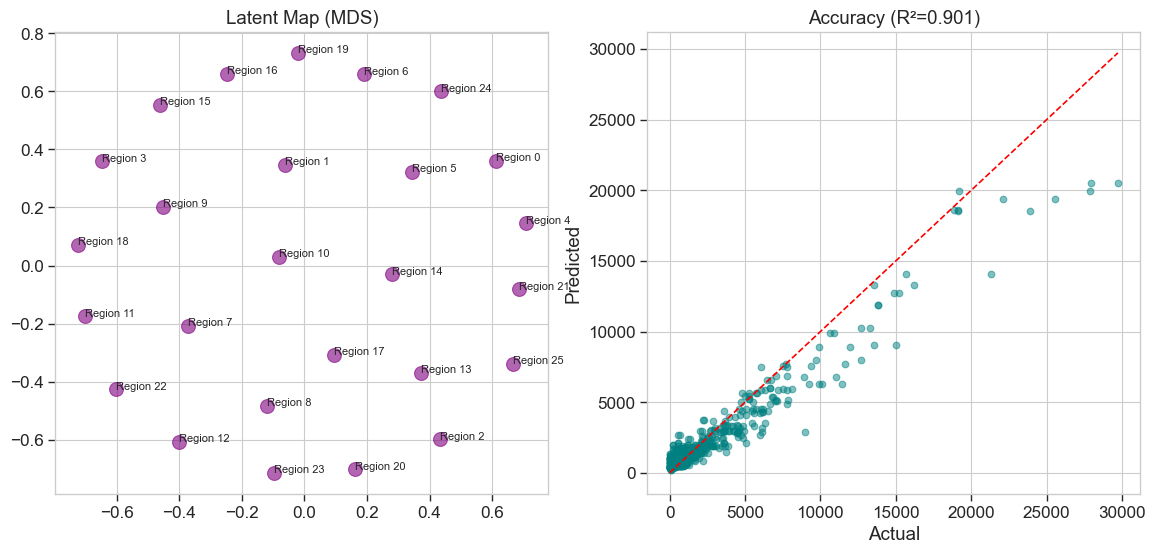

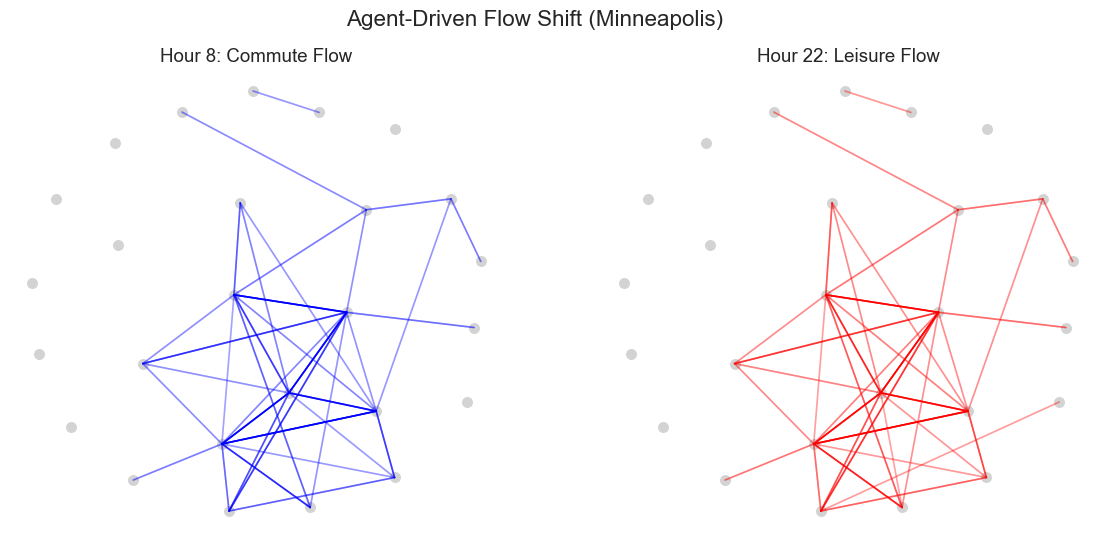


📊 FINAL INDEPENDENT MODEL COMPARISON
💾 Saved full metrics to Outputs/Metrics/Final_Benchmark_Results.csv

--- R² SCORES ---
Model          google.gemini-2.5-flash  meta.llama-4-maverick-17b-instruct  \
City                                                                         
Las Vegas                       0.9032                              0.8818   
Minneapolis                     0.9179                              0.9098   
NYC                             0.9667                              0.9670   
San Francisco                   0.8140                              0.8059   

Model          openai.gpt-5-mini  xai.grok-3-mini  
City                                               
Las Vegas                 0.8925           0.8841  
Minneapolis               0.9131           0.9012  
NYC                       0.9771           0.9664  
San Francisco             0.8054           0.8060  

--- CPC (Common Part of Commuters) SCORES ---
Model          google.gemini-2.5-flash  meta.ll

In [8]:
# ==============================================================================
# 🏁 CELL 7: MASTER EXPERIMENT LOOP
# ==============================================================================
cities_db = {
    "NYC": {
        "train": ["New-york-city-boroughs/new-york-city-boroughs.geojson Flow 6-9.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 10-13.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 14-17.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 18-21.csv"],
        "test": "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 22-25.csv",
        "state": "36", "county": "061",
        "bbox": (-74.02, 40.70, -73.93, 40.80), 
        "geojson": "CityHex20Exp/new-york-city-boroughs.geojson"
    },
    "Las Vegas": {
        "train": ["LasVegas/lasvagas.geojson Flow 6-9.csv", "LasVegas/lasvagas.geojson Flow 10-13.csv", "LasVegas/lasvagas.geojson Flow 14-17.csv", "LasVegas/lasvagas.geojson Flow 18-21.csv"],
        "test": "LasVegas/lasvagas.geojson Flow 22-25.csv",
        "state": "32", "county": "003",
        "bbox": (-115.35, 36.00, -115.00, 36.30), 
        "geojson": "CityHex20Exp/lasvagas.geojson"
    },
    "San Francisco": {
        "train": ["San_Francisco/sanfrancisco.geojson Flow 6-9.csv", "San_Francisco/sanfrancisco.geojson Flow 10-13.csv", "San_Francisco/sanfrancisco.geojson Flow 14-17.csv", "San_Francisco/sanfrancisco.geojson Flow 18-21.csv"],
        "test": "San_Francisco/sanfrancisco.geojson Flow 22-25.csv",
        "state": "06", "county": "075",
        "bbox": (-122.52, 37.70, -122.35, 37.83),
        "geojson": "CityHex20Exp/sanfrancisco.geojson"
    },
     "Minneapolis": {
        "train": ["Minneapolis/minneapolis.geojson Flow 6-9.csv", "Minneapolis/minneapolis.geojson Flow 10-13.csv", "Minneapolis/minneapolis.geojson Flow 14-17.csv", "Minneapolis/minneapolis.geojson Flow 18-21.csv"],
        "test": "Minneapolis/minneapolis.geojson Flow 22-25.csv",
        "state": "27", "county": "053",
        "bbox": (-93.29, 44.96, -93.24, 45.00),
        "geojson": "CityHex20Exp/minneapolis.geojson"
    }
}
# ==============================================================================
# 🏁 CELL 7: MASTER EXPERIMENT LOOP
# ==============================================================================
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create directories to store our outputs
os.makedirs("Outputs/Agent_JSONs", exist_ok=True)
os.makedirs("Outputs/Predicted_Flows", exist_ok=True)
os.makedirs("Outputs/Metrics", exist_ok=True)

# Helper function to calculate advanced mobility metrics
def calculate_advanced_metrics(y_true, y_pred):
    y_pred = np.maximum(0, y_pred) # Flow cannot be negative
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # CPC (Common Part of Commuters) - Standard urban mobility metric
    sum_true, sum_pred = np.sum(y_true), np.sum(y_pred)
    cpc = 2 * np.sum(np.minimum(y_true, y_pred)) / (sum_true + sum_pred) if (sum_true + sum_pred) > 0 else 0
    
    return r2, rmse, mae, cpc

comparison_results = []

for city, data in cities_db.items():
    print(f"\n" + "="*60)
    print(f"🏙️  STARTING BENCHMARK: {city}")
    print("="*60)
    
    # Use the MODELS list defined earlier in your notebook
    # Iterate through your existing config_list
    for cfg in config_list: 
        model_name = cfg['model']
        print(f"\n   🤖 MODEL: {model_name}...")
        safe_model_name = model_name.replace("/", "-")
        
        try:
            # 1. Build Agents
            llm_config = build_llm_config(model_name)
            llm_config["timeout"] = 300
            user_proxy, pop_gen, act_gen, pop_val, act_val, adv, skp, stat, ref = build_agents(llm_config)

            # 2. Population Stage
            print("      ⏳ Generating Population...")
            pop_prompt = make_population_prompt(city, data['county'], data['state'])
            
            # FIX: Replaced (...) with the actual arguments
            pop_res = run_stage_hybrid(
                county=data['county'], 
                state=data['state'], 
                stage="population",
                generator_agent=pop_gen, 
                prompt=pop_prompt, 
                user_proxy=user_proxy,
                self_verifier=pop_val, 
                advocate=adv, 
                skeptic=skp, 
                statistician=stat, 
                referee=ref, 
                hard_check_fn=hard_check_population
            )
            population_data = pop_res["accepted"]
            if not population_data: raise ValueError("Population generation failed.")
            
            # 💾 SAVE POPULATION JSON
            with open(f"Outputs/Agent_JSONs/{city}_{safe_model_name}_pop.json", "w") as f:
                json.dump(population_data, f, indent=4)

            # 3. Activity Stage
            print("      ⏳ Generating Activity Schedules...")
            act_prompt = make_activity_prompt(population_data)
            
            # Use the correct arguments for the activity stage
            act_res = run_stage_hybrid(
                county=data['county'], state=data['state'], stage="activity",
                generator_agent=act_gen, prompt=act_prompt, user_proxy=user_proxy,
                self_verifier=act_val, advocate=adv, skeptic=skp, statistician=stat, 
                referee=ref, hard_check_fn=hard_check_activity,
                hard_check_kwargs={"clusters": population_data["clusters"]}
            )
            activity_data = act_res["accepted"]
            if not activity_data: raise ValueError("Activity generation failed.")
            
            # 💾 SAVE ACTIVITY JSON
            with open(f"Outputs/Agent_JSONs/{city}_{safe_model_name}_act.json", "w") as f:
                json.dump(activity_data, f, indent=4)

            # 4. Mobility Handover
            print("      ⏳ Running Physical Simulation & ML Engine...")
            plan = MobilityPlanner(cfg) # (Using cfg as fixed previously)
            
            class DummySociologist:
                def __init__(self):
                    self.schedules = {}
            soc = DummySociologist()
            for cluster_act in activity_data["clusters_activity"]:
                key = f"{city}_{cluster_act['cluster_id']}"
                soc.schedules[key] = cluster_act 

            eng = HardDataEngine(city, soc, plan)
            eng.ingest_buildings_dynamic(data['bbox'], data['geojson'])
            
            # --- FIX 1: Use eng.building_data instead of eng.regions ---
            cluster_ids = [c['cluster_id'] for c in population_data["clusters"]]
            for i, (rid, rdata) in enumerate(eng.building_data.items()): 
                assigned_cluster = cluster_ids[i % len(cluster_ids)]
                rdata['cohort'] = f"{city}_{assigned_cluster}"
            
            # 5. Train & Predict
            eng.learn_topology(data['train'])
            raw_r2, true_flows, pred_flows = eng.train_and_test(data['train'], data['test'])
            
            # 📊 CALCULATE ALL METRICS
            r2, rmse, mae, cpc = calculate_advanced_metrics(true_flows, pred_flows)
            print(f"      🏆 {city} | R²: {r2:.4f} | CPC: {cpc:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")
            
            comparison_results.append({
                "City": city, 
                "Model": model_name, 
                "R2_Score": round(r2, 4),
                "CPC": round(cpc, 4),
                "RMSE": round(rmse, 2),
                "MAE": round(mae, 2)
            })
            
            # 💾 SAVE PREDICTED OD FLOWS FOR PLOTTING
            if r2 > 0.0:
                test_df = pd.read_csv(data['test'])
                
                # --- FIX: Filter out self-links so the lengths match (676 -> 650) ---
                orig_col = 'Origin' if 'Origin' in test_df.columns else 'origin'
                dest_col = 'Destination' if 'Destination' in test_df.columns else 'destination'
                test_df = test_df[test_df[orig_col] != test_df[dest_col]].copy()
                
                test_df['Actual_Flow'] = true_flows
                test_df['Predicted_Flow'] = np.maximum(0, pred_flows)
                
                # Assign the cluster to the export data
                def get_cluster(orig_id):
                    orig_str = f"Region {str(orig_id).replace('Region ', '').strip()}"
                    region_data = eng.building_data.get(orig_str, {})
                    return region_data.get('cohort', f'{city}_Unknown')
                
                test_df['Cluster'] = test_df[orig_col].apply(get_cluster)
                    
                test_df.to_csv(f"Outputs/Predicted_Flows/{city}_{safe_model_name}_OD_Flows.csv", index=False)
                
            if r2 > 0.8: plot_results(city, eng, r2, true_flows, pred_flows, soc)
            
        except Exception as e:
            print(f"      ❌ FAILED: {model_name} on {city} - Error: {e}")
            comparison_results.append({
                "City": city, "Model": model_name, 
                "R2_Score": 0.0, "CPC": 0.0, "RMSE": 0.0, "MAE": 0.0
            })

# ==============================================================================
# 📊 FINAL METRICS EXPORT
# ==============================================================================
print("\n" + "="*60)
print("📊 FINAL INDEPENDENT MODEL COMPARISON")
print("="*60)

df_results = pd.DataFrame(comparison_results)
if not df_results.empty:
    # Save the raw metrics table
    df_results.to_csv("Outputs/Metrics/Final_Benchmark_Results.csv", index=False)
    print("💾 Saved full metrics to Outputs/Metrics/Final_Benchmark_Results.csv\n")
    
    # --- FIX: Use pivot_table with aggfunc='max' to handle duplicates safely ---
    print("--- R² SCORES ---")
    print(df_results.pivot_table(index="City", columns="Model", values="R2_Score", aggfunc="max"))
    
    print("\n--- CPC (Common Part of Commuters) SCORES ---")
    print(df_results.pivot_table(index="City", columns="Model", values="CPC", aggfunc="max"))